# Tier 4.1 — CRAG (Corrective RAG): Full Analysis

**Benchmark:** BSARD official test split — 222 questions
**Experiments:** 4 CRAG runs (canonical hybrid, BM25 ablation, mGTE/aligned reference)
**Primary metric:** Recall@10 | **Canonical anchor:** `hybrid_rrf_k60` (R@10=0.4021); secondary anchor `bm25_tuned_k11.5_b0.25` (R@10=0.2651)
**First-stage retrievers:** BM25 Okapi (k1=1.5, b=0.25, lemmatize, text_only); hybrid RRF (BM25 + mE5-large concat_2x, RRF k=60, first_stage_k=100)
**LLM backbone:** `llama3.1:8b` via Ollama (temp=0.0, identical to T4.0 and T4.2)
**Evaluator:** Collective sufficiency judgment — single LLaMA 3.1 8B call per iteration (`eval_k=20`)
**Corpus:** 22,633 deduplicated articles (`output/bsard_articles_dedup.parquet`)

> **T4.0 comparison convention.** This notebook compares CRAG **only against the
> T4.0-hybrid top-20 variant** (`llm_rerank_binary_top20_hybrid_rrf_k60_test`, R@10=0.4347)
> because CRAG's `eval_k=20` defines the same candidate-pool size. The T4.0 top-50 variants
> use a different pool size (top_n=50) and are **not** apples-to-apples comparisons for the
> CRAG agentic-loop delta — they are excluded here. All comparisons against T4.0 are also
> capped at **R@k ≤ R@20** for the same reason (CRAG only judges the top-20, and the T4.0
> top-20 pool plateaus at R@20).

---

### Experiment Map

| Experiment ID | Backbone | First Stage | Split | Role |
|---|---|---|---|---|
| `crag_hybrid_rrf_k60_test_v2` | hybrid RRF k=60 | BM25 + mE5-large RRF | test | **Canonical — primary result** |
| `crag_bm25_test_v2` | BM25 tuned | BM25 only | test | First-stage ablation |
| `crag_hybrid_aligned_test_v2` | hybrid linear α=0.9 (mE5-large) | early hybrid blend | test | Reference (older blend) |
| `crag_bm25_test` | BM25 tuned (mGTE evaluator) | BM25 only | test | Appendix — evaluator ablation |

### Thesis ablation comparisons

| Comparison | Measures |
|---|---|
| T4.1-hybrid vs `hybrid_rrf_k60` (T3-A) | Value of CRAG correction loop on hybrid pool (PRIMARY) |
| T4.1-hybrid vs T4.1-BM25 | Pool quality effect (same CRAG loop, different first stage) |
| T4.1-hybrid vs **T4.0-hybrid top-20** | Agentic value (CRAG loop vs non-agentic LLM re-rank, matched candidate pool size eval_k=20) |
| T4.1-BM25 vs T1 BM25 anchor | CRAG correction loop value over raw BM25 |
| T4.1-BM25 vs T4.2-BM25 (ReAct) | CRAG vs ReAct on identical BM25 backbone |
| LLaMA vs mGTE evaluator (T4.1-BM25 vs `crag_bm25_test`) | Evaluator calibration ablation |


## 0. Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns

ROOT       = Path().resolve().parent.parent.parent
CRAG_DIR   = ROOT / 'output' / 'results' / 'agentic' / 'CRAG'
LLM_DIR    = ROOT / 'output' / 'results' / 'agentic' / 'llm_judge' / 'llm_rerank'
REACT_DIR  = ROOT / 'output' / 'results' / 'agentic' / 'ReAct'
SPARSE_DIR = ROOT / 'output' / 'results' / 'sparse_retrieval'
HYBRID_DIR = ROOT / 'output' / 'results' / 'hybrid'
DENSE_DIR  = ROOT / 'output' / 'results' / 'dense_retrieval'
FIG_DIR    = Path().resolve() / 'figures'
FIG_DIR.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})

# ── Colour palette ─────────────────────────────────────────────────────────
COLOR_CRAG_HYB   = '#16a085'   # dark-teal — T4.1 CRAG hybrid (canonical PRIMARY)
COLOR_CRAG_BM25  = '#1abc9c'   # teal      — T4.1 CRAG BM25 (first-stage ablation)
COLOR_CRAG_M     = '#95a5a6'   # grey      — T4.1 CRAG mGTE (appendix)
COLOR_ALIGNED    = '#117a65'   # darker teal — T4.1 CRAG hybrid aligned (older blend, reference)
COLOR_T40        = '#8e44ad'   # purple    — T4.0 LLM re-rank BM25
COLOR_T40_HYB    = '#5b2c6f'   # dark-purple — T4.0 LLM re-rank hybrid
COLOR_REACT      = '#e67e22'   # orange    — T4.2 ReAct BM25
COLOR_BM25       = '#e74c3c'   # red       — T1 BM25 anchor
COLOR_RRF        = '#f39c12'   # amber     — T3-A hybrid_rrf_k60 anchor (canonical anchor)
COLOR_SGDR       = '#2e86c1'   # blue      — T3-C SGDR
COLOR_DENSE      = '#27ae60'   # green     — T2 mE5-large dense


In [2]:
# ── Load T4.1 CRAG results ─────────────────────────────────────────────────
crag_hyb_d   = json.loads((CRAG_DIR / 'crag_hybrid_rrf_k60_test_v2.json').read_text(encoding='utf-8'))  # CANONICAL
crag_bm25_d  = json.loads((CRAG_DIR / 'crag_bm25_test_v2.json').read_text(encoding='utf-8'))             # ablation
crag_mgte_d  = json.loads((CRAG_DIR / 'crag_bm25_test.json').read_text(encoding='utf-8'))                # mGTE appendix
crag_align_d = json.loads((CRAG_DIR / 'crag_hybrid_aligned_test_v2.json').read_text(encoding='utf-8'))   # older blend ref

# ── Load cross-tier anchors ────────────────────────────────────────────────
bm25_d   = json.loads((SPARSE_DIR / 'bm25_tuned_k11.5_b0.25_test.json').read_text(encoding='utf-8'))
rrf_d    = json.loads((HYBRID_DIR / 'hybrid_rrf_k60_test.json').read_text(encoding='utf-8'))             # canonical anchor
sgdr_d   = json.loads((HYBRID_DIR / 'hybrid_sgdr_k1000_test.json').read_text(encoding='utf-8'))

# T4.0 comparison: ONLY the top-20 variant (matched to CRAG's eval_k=20 pool).
# The top-50 T4.0 variants (BM25 and hybrid) use a different pool size and are
# excluded here per the apples-to-apples convention stated at the top.
t40_hyb20_d = json.loads((LLM_DIR / 'llm_rerank_binary_top20_hybrid_rrf_k60_test.json').read_text(encoding='utf-8'))

react_d  = json.loads((REACT_DIR  / 'react_bm25_test.json').read_text(encoding='utf-8'))

dense_path = DENSE_DIR / 'dense_me5_large_concat2x_zeroshot_test.json'
dense_d    = json.loads(dense_path.read_text(encoding='utf-8')) if dense_path.exists() else None

# Helper functions
def m(d):     return d['metrics']
def r10(d):   return m(d).get('Recall@10', 0)
def r20(d):   return m(d).get('Recall@20', 0)
def r100(d):  return m(d).get('Recall@100', 0)
def mrr10(d): return m(d).get('MRR@10', 0)
def lat_ms(d):
    return m(d).get('T0/latency_mean_ms', d.get('latency_ms_mean', 0))

print('T4.1 CRAG results loaded:')
for label, d in [
    ('CRAG hybrid_rrf_k60 (canonical)',  crag_hyb_d),
    ('CRAG BM25         (ablation)',     crag_bm25_d),
    ('CRAG hybrid aligned (reference)',  crag_align_d),
    ('CRAG BM25 mGTE   (appendix)',      crag_mgte_d),
]:
    print(f'  {label:<38} R@10={r10(d):.4f}  R@20={r20(d):.4f}  '
          f'MRR@10={mrr10(d):.4f}  lat={lat_ms(d)/1000:.1f}s')

print('\nCross-tier anchors:')
for label, d in [
    ('T1 BM25 tuned k11.5_b0.25',              bm25_d),
    ('T3-A hybrid_rrf_k60 (anchor)',            rrf_d),
    ('T3-C SGDR k=1000',                        sgdr_d),
    ('T4.0 Binary hybrid TOP-20 (matched pool)',t40_hyb20_d),
    ('T4.2 ReAct BM25',                         react_d),
]:
    print(f'  {label:<42} R@10={r10(d):.4f}  R@20={r20(d):.4f}  '
          f'MRR@10={mrr10(d):.4f}  lat={lat_ms(d)/1000:.2f}s')


T4.1 CRAG results loaded:
  CRAG hybrid_rrf_k60 (canonical)        R@10=0.4263  R@20=0.4653  MRR@10=0.3938  lat=13.9s
  CRAG BM25         (ablation)           R@10=0.3012  R@20=0.3271  MRR@10=0.3322  lat=17.3s
  CRAG hybrid aligned (reference)        R@10=0.4282  R@20=0.4858  MRR@10=0.4002  lat=15.6s
  CRAG BM25 mGTE   (appendix)            R@10=0.2427  R@20=0.3072  MRR@10=0.2683  lat=68.3s

Cross-tier anchors:
  T1 BM25 tuned k11.5_b0.25                  R@10=0.2651  R@20=0.3334  MRR@10=0.2511  lat=0.08s
  T3-A hybrid_rrf_k60 (anchor)               R@10=0.4021  R@20=0.4648  MRR@10=0.3402  lat=0.32s
  T3-C SGDR k=1000                           R@10=0.3655  R@20=0.4724  MRR@10=0.3271  lat=0.34s
  T4.0 Binary hybrid TOP-20 (matched pool)   R@10=0.4347  R@20=0.4648  MRR@10=0.3939  lat=0.08s
  T4.2 ReAct BM25                            R@10=0.2266  R@20=0.2363  MRR@10=0.2201  lat=18.51s


## A. Full Results Table

In [3]:
def make_crag_row(d, label, role):
    met  = d['metrics']
    hp   = d.get('hyperparameters', {})
    loop = d.get('crag_loop_stats', {})
    sig  = d.get('significance_vs_anchor', {})
    return {
        'Experiment':    label,
        'Role':          role,
        'Backbone':      hp.get('retrieval_backbone', '—'),
        'Evaluator':     hp.get('evaluator', '—'),
        'eval_k':        hp.get('eval_k', '—'),
        'R@1':           met.get('Recall@1', 0),
        'R@5':           met.get('Recall@5', 0),
        'R@10':          met.get('Recall@10', 0),
        'R@20':          met.get('Recall@20', 0),
        'MRR@10':        met.get('MRR@10', 0),
        'NDCG@10':       met.get('NDCG@10', 0),
        'MAP@100':       met.get('MAP@100', 0),
        'Lat (s)':       lat_ms(d) / 1000,
        'Correct@0':     loop.get('fraction_queries_correct_first_pass', None),
        'Rewritten':     loop.get('fraction_queries_rewritten', None),
        'Hit limit':     loop.get('fraction_queries_terminated_by_limit', None),
        'p (R@10)':      sig.get('p_value_recall10'),
        'Sig':           sig.get('significant'),
    }

def make_anchor_row(d, label, role):
    met = d['metrics']
    return {
        'Experiment': label, 'Role': role,
        'Backbone': '—', 'Evaluator': '—', 'eval_k': '—',
        'R@1': met.get('Recall@1', 0), 'R@5': met.get('Recall@5', 0),
        'R@10': met.get('Recall@10', 0), 'R@20': met.get('Recall@20', 0),
        'MRR@10': met.get('MRR@10', 0), 'NDCG@10': met.get('NDCG@10', 0),
        'MAP@100': met.get('MAP@100', 0),
        'Lat (s)': lat_ms(d) / 1000,
        'Correct@0': None, 'Rewritten': None, 'Hit limit': None,
        'p (R@10)': None, 'Sig': None,
    }

# T4.0 row only includes the matched-pool top-20 variant. Top-50 T4.0 anchors
# are deliberately excluded — they use a different pool size and are not
# apples-to-apples for CRAG (eval_k=20).
rows = [
    make_crag_row(crag_hyb_d,    'T4.1 CRAG hybrid_rrf_k60 (canonical)',   'Canonical'),
    make_crag_row(crag_bm25_d,   'T4.1 CRAG BM25 v2 (first-stage ablation)','Ablation'),
    make_crag_row(crag_align_d,  'T4.1 CRAG hybrid aligned (reference)',   'Reference'),
    make_crag_row(crag_mgte_d,   'T4.1 CRAG BM25 mGTE (appendix)',         'Appendix'),
    make_anchor_row(rrf_d,        '[T3-A] hybrid_rrf_k60',                  'T3-A anchor'),
    make_anchor_row(t40_hyb20_d,  '[T4.0] LLM re-rank binary hybrid TOP-20 (matched pool)', 'T4.0 anchor (matched)'),
    make_anchor_row(react_d,      '[T4.2] ReAct BM25',                      'T4.2 anchor'),
    make_anchor_row(sgdr_d,       '[T3-C] SGDR k=1000',                     'T3-C anchor'),
    make_anchor_row(bm25_d,       '[T1]   BM25 tuned k11.5_b0.25',          'T1 anchor'),
]
df = pd.DataFrame(rows)

fmt = {
    'R@1': '{:.4f}', 'R@5': '{:.4f}', 'R@10': '{:.4f}', 'R@20': '{:.4f}',
    'MRR@10': '{:.4f}', 'NDCG@10': '{:.4f}',
    'Lat (s)': '{:.2f}',
    'Correct@0': '{:.1%}', 'Rewritten': '{:.1%}', 'Hit limit': '{:.1%}',
    'p (R@10)': '{:.4f}',
}
# CRAG eval_k=20 → R@k for k>20 is dominated by the first-stage retriever
# (CRAG only judges the top-20). Display is capped at R@20.
cols = ['Experiment', 'Role', 'eval_k',
        'R@1', 'R@5', 'R@10', 'R@20',
        'MRR@10', 'NDCG@10', 'Lat (s)',
        'Correct@0', 'Rewritten', 'Hit limit', 'p (R@10)', 'Sig']
display(df[cols].style.format(fmt, na_rep='—').hide(axis='index'))


Experiment,Role,eval_k,R@1,R@5,R@10,R@20,MRR@10,NDCG@10,Lat (s),Correct@0,Rewritten,Hit limit,p (R@10),Sig
T4.1 CRAG hybrid_rrf_k60 (canonical),Canonical,20,0.1365,0.3520,0.4263,0.4653,0.3938,0.3461,13.90,96.4%,3.6%,0.0%,0.0463,True
T4.1 CRAG BM25 v2 (first-stage ablation),Ablation,20,0.1274,0.2504,0.3012,0.3271,0.3322,0.2651,17.27,89.6%,10.4%,0.0%,—,—
T4.1 CRAG hybrid aligned (reference),Reference,20,0.1497,0.3499,0.4282,0.4858,0.4002,0.4457,15.63,95.9%,4.1%,0.5%,—,—
T4.1 CRAG BM25 mGTE (appendix),Appendix,5,0.1157,0.1999,0.2427,0.3072,0.2683,0.2920,68.26,21.2%,78.8%,63.5%,—,—
[T3-A] hybrid_rrf_k60,T3-A anchor,—,0.1143,0.2910,0.4021,0.4648,0.3402,0.3094,0.32,—,—,—,—,—
[T4.0] LLM re-rank binary hybrid TOP-20 (matched pool),T4.0 anchor (matched),—,0.1355,0.3635,0.4347,0.4648,0.3939,0.3516,0.08,—,—,—,—,—
[T4.2] ReAct BM25,T4.2 anchor,—,0.0579,0.1783,0.2266,0.2363,0.2201,0.1834,18.51,—,—,—,—,—
[T3-C] SGDR k=1000,T3-C anchor,—,0.0978,0.2599,0.3655,0.4724,0.3271,0.2851,0.34,—,—,—,—,—
[T1] BM25 tuned k11.5_b0.25,T1 anchor,—,0.1117,0.2020,0.2651,0.3334,0.2511,0.2221,0.08,—,—,—,—,—


## 1. Recall@k Curves (k ≤ eval_k=20) — CRAG vs All Baselines

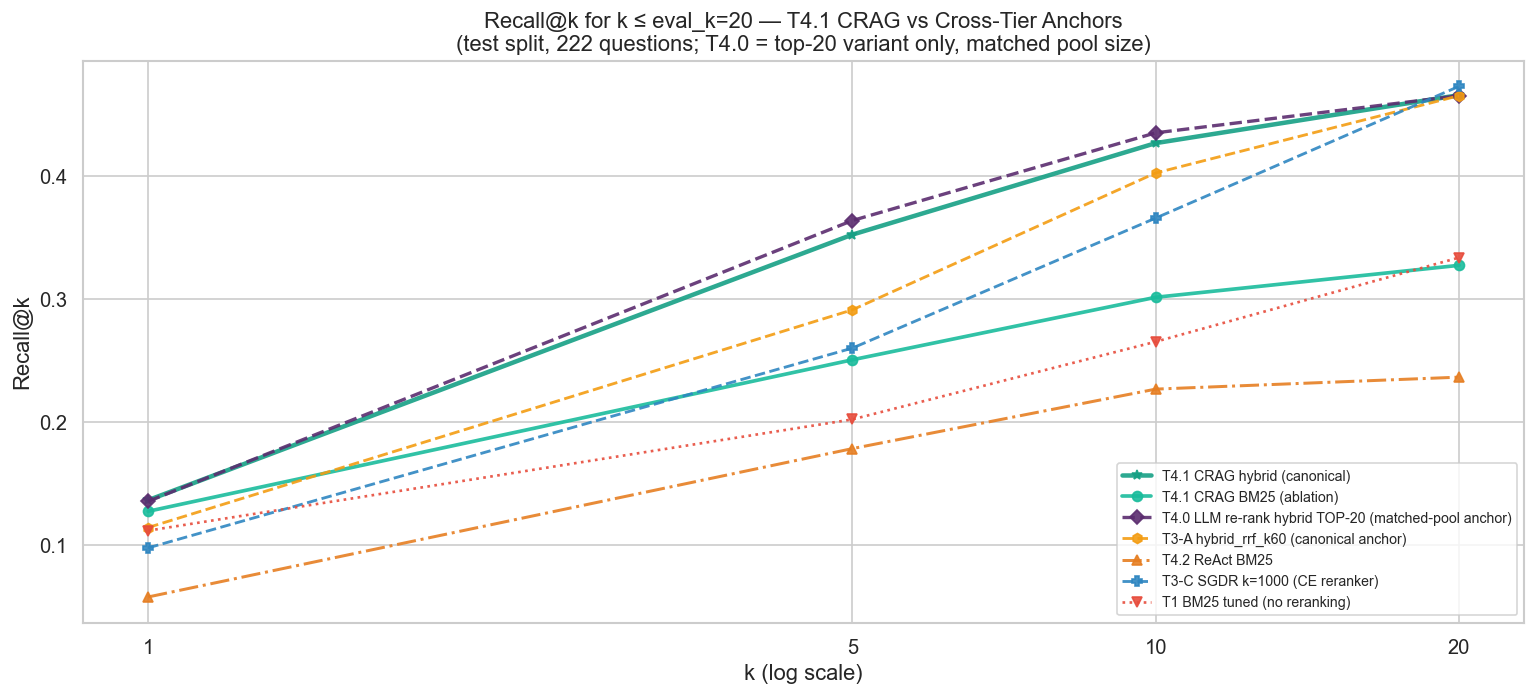

Notes:
  • Curve is truncated at k = eval_k = 20: CRAG only judges the top-20 candidates,
    so R@k for k > 20 is the first-stage retriever passing through (not a CRAG result).
  • T4.0 anchor is restricted to the top-20 variant — same candidate-pool size as CRAG.
  • For first-stage-only systems (BM25, T3-A, T3-C), full R@k curves are in the upstream tier notebooks.


In [4]:
# CRAG only judges the top eval_k=20 — recall beyond k=20 is the first-stage
# retriever passing through and does not reflect CRAG's contribution.
# T4.0 comparison is restricted to the top-20 variant (matched pool).
K_VALS = [1, 5, 10, 20]
K_COLS = [f'Recall@{k}' for k in K_VALS]

systems = [
    (crag_hyb_d,   'T4.1 CRAG hybrid (canonical)',                       COLOR_CRAG_HYB,  '-',  '*', 2.7),
    (crag_bm25_d,  'T4.1 CRAG BM25 (ablation)',                          COLOR_CRAG_BM25, '-',  'o', 2.2),
    (t40_hyb20_d,  'T4.0 LLM re-rank hybrid TOP-20 (matched-pool anchor)', COLOR_T40_HYB,  '--', 'D', 2.0),
    (rrf_d,        'T3-A hybrid_rrf_k60 (canonical anchor)',             COLOR_RRF,       '--', 'h', 1.7),
    (react_d,      'T4.2 ReAct BM25',                                    COLOR_REACT,     '-.', '^', 1.8),
    (sgdr_d,       'T3-C SGDR k=1000 (CE reranker)',                     COLOR_SGDR,      '--', 'P', 1.7),
    (bm25_d,       'T1 BM25 tuned (no reranking)',                       COLOR_BM25,      ':',  'v', 1.6),
]

fig, ax = plt.subplots(figsize=(13, 6))
for d, label, color, ls, marker, lw in systems:
    ys = [m(d).get(c, 0) for c in K_COLS]
    ax.plot(K_VALS, ys, label=label, color=color, linewidth=lw,
            linestyle=ls, marker=marker, markersize=6, alpha=0.9)

ax.set_xscale('log')
ax.set_xlabel('k (log scale)')
ax.set_ylabel('Recall@k')
ax.set_title('Recall@k for k ≤ eval_k=20 — T4.1 CRAG vs Cross-Tier Anchors\n'
             '(test split, 222 questions; T4.0 = top-20 variant only, matched pool size)')
ax.set_xticks(K_VALS)
ax.set_xticklabels(K_VALS)
ax.legend(fontsize=8.5, loc='lower right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_recall_at_k.png', bbox_inches='tight')
plt.show()

print('Notes:')
print('  • Curve is truncated at k = eval_k = 20: CRAG only judges the top-20 candidates,')
print('    so R@k for k > 20 is the first-stage retriever passing through (not a CRAG result).')
print('  • T4.0 anchor is restricted to the top-20 variant — same candidate-pool size as CRAG.')
print('  • For first-stage-only systems (BM25, T3-A, T3-C), full R@k curves are in the upstream tier notebooks.')


## 2. R@10 Bar Chart — T4.1 CRAG vs All Systems

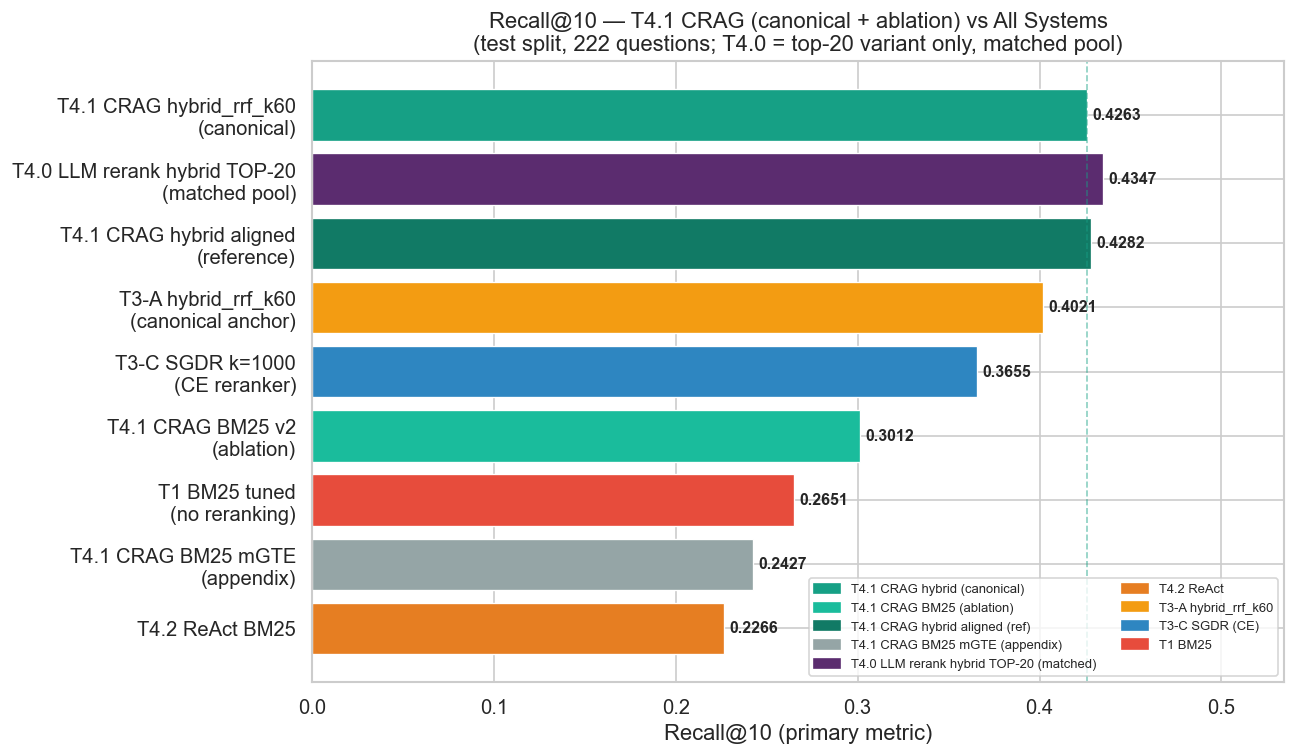

In [5]:
systems_bar = [
    ('T4.2 ReAct BM25',                                  r10(react_d),      COLOR_REACT),
    ('T4.1 CRAG BM25 mGTE\n(appendix)',                 r10(crag_mgte_d),  COLOR_CRAG_M),
    ('T1 BM25 tuned\n(no reranking)',                   r10(bm25_d),       COLOR_BM25),
    ('T4.1 CRAG BM25 v2\n(ablation)',                   r10(crag_bm25_d),  COLOR_CRAG_BM25),
    ('T3-C SGDR k=1000\n(CE reranker)',                 r10(sgdr_d),       COLOR_SGDR),
    ('T3-A hybrid_rrf_k60\n(canonical anchor)',         r10(rrf_d),        COLOR_RRF),
    ('T4.1 CRAG hybrid aligned\n(reference)',           r10(crag_align_d), COLOR_ALIGNED),
    ('T4.0 LLM rerank hybrid TOP-20\n(matched pool)',   r10(t40_hyb20_d),  COLOR_T40_HYB),
    ('T4.1 CRAG hybrid_rrf_k60\n(canonical)',           r10(crag_hyb_d),   COLOR_CRAG_HYB),
]
lbls = [s[0] for s in systems_bar]
vals = [s[1] for s in systems_bar]
cols = [s[2] for s in systems_bar]

fig, ax = plt.subplots(figsize=(11, 6.5))
bars = ax.barh(lbls, vals, color=cols, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, vals):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9.5, fontweight='bold')

# CRAG hybrid (canonical) marker
ax.axvline(r10(crag_hyb_d), color=COLOR_CRAG_HYB, linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Recall@10 (primary metric)')
ax.set_title('Recall@10 — T4.1 CRAG (canonical + ablation) vs All Systems\n'
             '(test split, 222 questions; T4.0 = top-20 variant only, matched pool)')
ax.set_xlim(0, max(vals) + 0.10)

legend_items = [
    mpatches.Patch(color=COLOR_CRAG_HYB,  label='T4.1 CRAG hybrid (canonical)'),
    mpatches.Patch(color=COLOR_CRAG_BM25, label='T4.1 CRAG BM25 (ablation)'),
    mpatches.Patch(color=COLOR_ALIGNED,   label='T4.1 CRAG hybrid aligned (ref)'),
    mpatches.Patch(color=COLOR_CRAG_M,    label='T4.1 CRAG BM25 mGTE (appendix)'),
    mpatches.Patch(color=COLOR_T40_HYB,   label='T4.0 LLM rerank hybrid TOP-20 (matched)'),
    mpatches.Patch(color=COLOR_REACT,     label='T4.2 ReAct'),
    mpatches.Patch(color=COLOR_RRF,       label='T3-A hybrid_rrf_k60'),
    mpatches.Patch(color=COLOR_SGDR,      label='T3-C SGDR (CE)'),
    mpatches.Patch(color=COLOR_BM25,      label='T1 BM25'),
]
ax.legend(handles=legend_items, fontsize=7.8, loc='lower right', ncol=2)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_r10_comparison.png', bbox_inches='tight')
plt.show()


## 3. CRAG Correction Loop Statistics

Breakdown of how queries were routed through the CRAG loop.

In [6]:
loop_hyb  = crag_hyb_d.get('crag_loop_stats', {})
loop_v2   = crag_bm25_d.get('crag_loop_stats', {})
loop_mgt  = crag_mgte_d.get('crag_loop_stats', {})
loop_alig = crag_align_d.get('crag_loop_stats', {})

def loop_row(label, loop):
    return {
        'Experiment':              label,
        'n_queries':               loop['n_queries'],
        'Mean iter / query':       loop['mean_iterations_per_query'],
        'Correct first-pass':      loop['fraction_queries_correct_first_pass'],
        'Rewritten ≥1':            loop['fraction_queries_rewritten'],
        'Used aspect rewrite':     loop.get('fraction_queries_used_aspect_rewrite', 0),
        'Hit iteration limit':     loop['fraction_queries_terminated_by_limit'],
        'No-change termination':   loop.get('fraction_queries_no_change_termination', 0),
        'Dist. Correct (all iter)':loop['distribution_Correct'],
        'Dist. Incorrect (all iter)':loop['distribution_Incorrect'],
    }

loop_df = pd.DataFrame([
    loop_row('CRAG hybrid (canonical, LLaMA evaluator)', loop_hyb),
    loop_row('CRAG BM25 v2 (ablation, LLaMA evaluator)',  loop_v2),
    loop_row('CRAG hybrid aligned (reference, LLaMA)',    loop_alig),
    loop_row('CRAG BM25 mGTE (appendix, mGTE evaluator)', loop_mgt),
])

pct_cols = ['Correct first-pass', 'Rewritten ≥1', 'Used aspect rewrite',
            'Hit iteration limit', 'No-change termination',
            'Dist. Correct (all iter)', 'Dist. Incorrect (all iter)']
fmt = {c: '{:.1%}' for c in pct_cols}
fmt['Mean iter / query'] = '{:.3f}'
display(loop_df.style.format(fmt).hide(axis='index'))

print('\nKey findings:')
print(f'  CRAG hybrid (canonical): {loop_hyb["fraction_queries_correct_first_pass"]:.1%} Correct first-pass '
      f'→ only {loop_hyb["fraction_queries_rewritten"]:.1%} of queries needed rewriting.')
print(f'  CRAG BM25 v2 (ablation): {loop_v2["fraction_queries_correct_first_pass"]:.1%} Correct first-pass '
      f'→ {loop_v2["fraction_queries_rewritten"]:.1%} rewritten.')
print(f'  → Hybrid pool surfaces relevant docs more often, so the LLM evaluator marks more queries '
      f'Correct on the first pass ({loop_hyb["fraction_queries_correct_first_pass"]:.1%} vs '
      f'{loop_v2["fraction_queries_correct_first_pass"]:.1%}).')
print(f'  CRAG mGTE (appendix):  {loop_mgt["fraction_queries_correct_first_pass"]:.1%} Correct first-pass, '
      f'{loop_mgt["fraction_queries_terminated_by_limit"]:.1%} hit limit '
      f'→ severely miscalibrated; LLaMA collective is the correct evaluator.')


Experiment,n_queries,Mean iter / query,Correct first-pass,Rewritten ≥1,Used aspect rewrite,Hit iteration limit,No-change termination,Dist. Correct (all iter),Dist. Incorrect (all iter)
"CRAG hybrid (canonical, LLaMA evaluator)",222,1.041,96.4%,3.6%,0.0%,0.0%,0.0%,96.1%,3.9%
"CRAG BM25 v2 (ablation, LLaMA evaluator)",222,1.158,89.6%,10.4%,0.0%,0.0%,0.9%,85.6%,14.4%
"CRAG hybrid aligned (reference, LLaMA)",222,1.059,95.9%,4.1%,0.0%,0.5%,0.0%,94.0%,6.0%
"CRAG BM25 mGTE (appendix, mGTE evaluator)",222,2.477,21.2%,78.8%,0.0%,63.5%,0.0%,14.7%,85.3%



Key findings:
  CRAG hybrid (canonical): 96.4% Correct first-pass → only 3.6% of queries needed rewriting.
  CRAG BM25 v2 (ablation): 89.6% Correct first-pass → 10.4% rewritten.
  → Hybrid pool surfaces relevant docs more often, so the LLM evaluator marks more queries Correct on the first pass (96.4% vs 89.6%).
  CRAG mGTE (appendix):  21.2% Correct first-pass, 63.5% hit limit → severely miscalibrated; LLaMA collective is the correct evaluator.


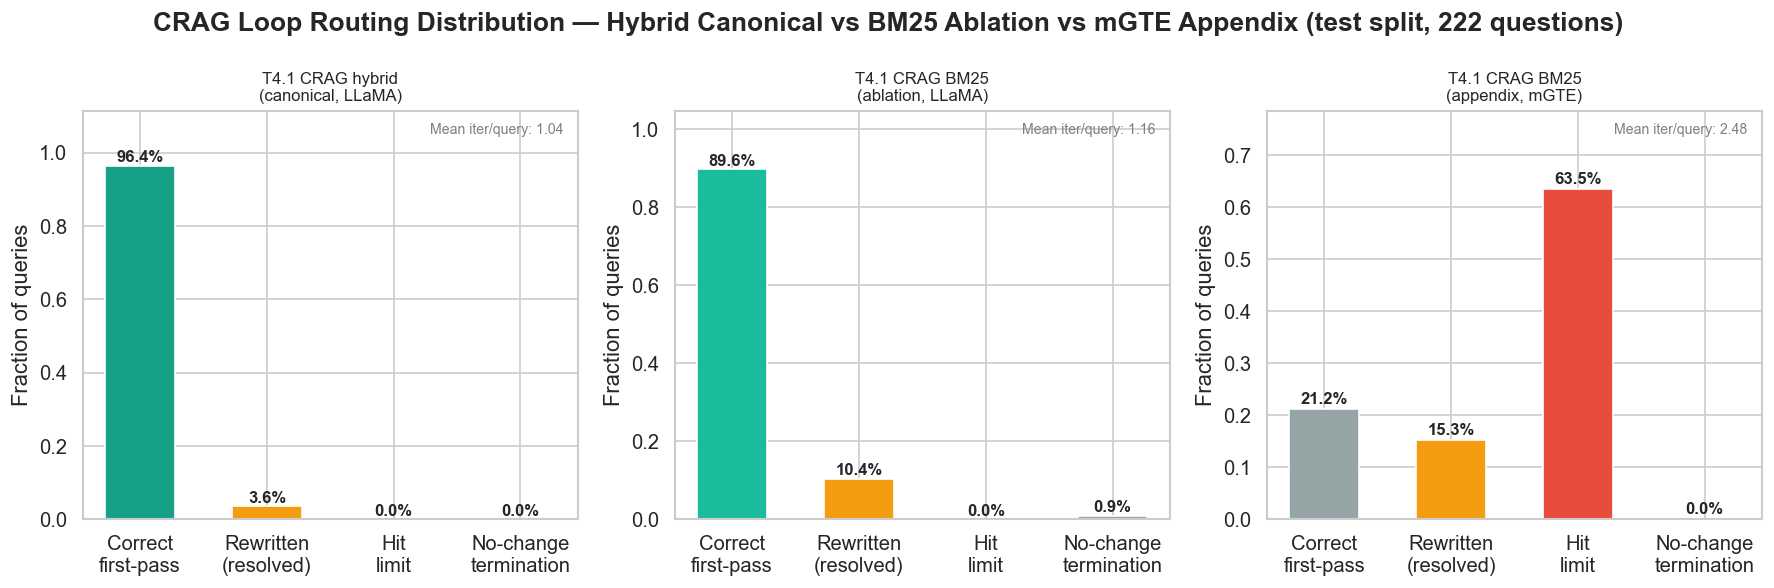

In [7]:
# ── Stacked routing breakdown chart ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

panels = [
    (loop_hyb,  COLOR_CRAG_HYB,  'T4.1 CRAG hybrid\n(canonical, LLaMA)'),
    (loop_v2,   COLOR_CRAG_BM25, 'T4.1 CRAG BM25\n(ablation, LLaMA)'),
    (loop_mgt,  COLOR_CRAG_M,    'T4.1 CRAG BM25\n(appendix, mGTE)'),
]

for ax, (loop, color_correct, title) in zip(axes, panels):
    correct  = loop['fraction_queries_correct_first_pass']
    rewrite  = loop['fraction_queries_rewritten'] - loop['fraction_queries_terminated_by_limit']
    limit    = loop['fraction_queries_terminated_by_limit']
    no_change = loop.get('fraction_queries_no_change_termination', 0)

    cats  = ['Correct\nfirst-pass', 'Rewritten\n(resolved)', 'Hit\nlimit', 'No-change\ntermination']
    vals  = [correct, rewrite, limit, no_change]
    cols_ = [color_correct, '#f39c12', '#e74c3c', '#95a5a6']

    bars = ax.bar(cats, vals, color=cols_, edgecolor='white', width=0.55)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.1%}', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('Fraction of queries')
    ax.set_ylim(0, max(vals) + 0.15)
    ax.text(0.97, 0.97, f'Mean iter/query: {loop["mean_iterations_per_query"]:.2f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8.5, color='gray')

plt.suptitle('CRAG Loop Routing Distribution — Hybrid Canonical vs BM25 Ablation vs mGTE Appendix '
             '(test split, 222 questions)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_loop_stats.png', bbox_inches='tight')
plt.show()


## 4. Per-Iteration Recall Progression

How retrieval quality evolves across CRAG iterations for the 35 queries that were rewritten.
Recall is measured over the `eval_k` documents shown to the LLM — not the full top-100 pool.

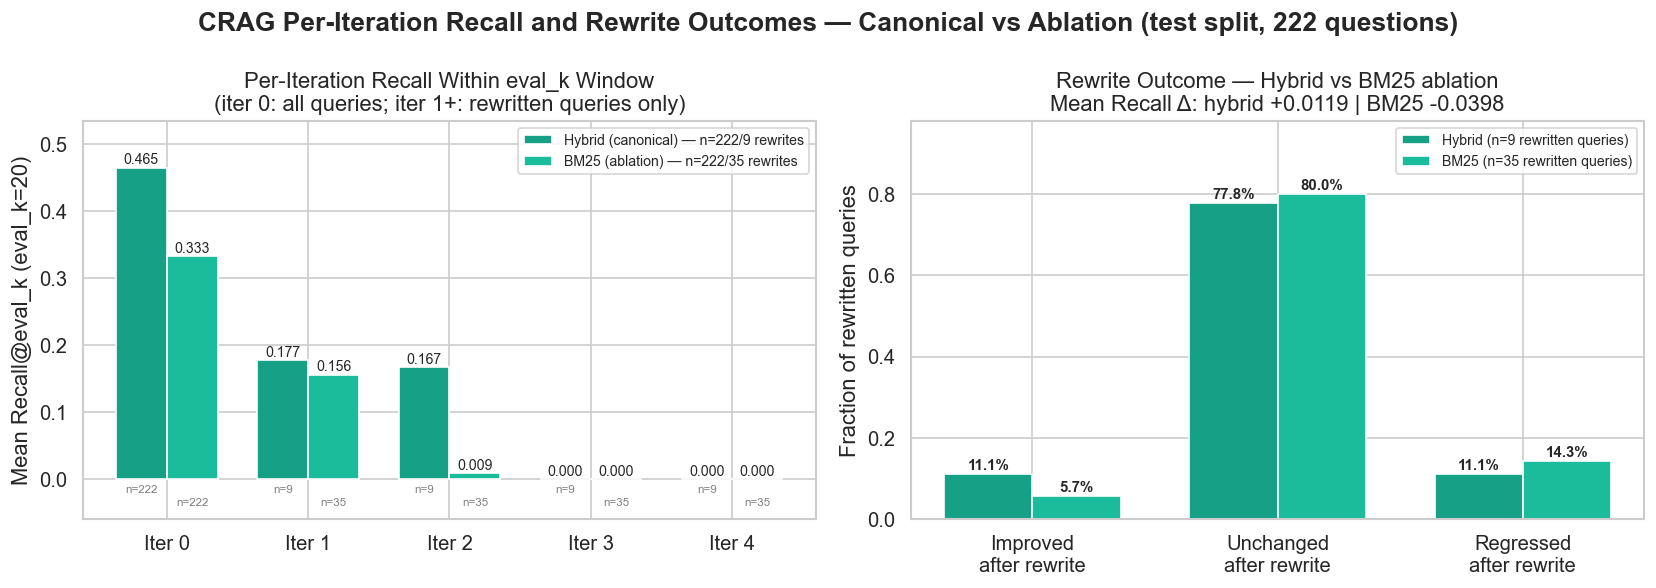


Interpretation:
  Hybrid: only 9/222 queries rewritten (4.1%); mean Δ +0.0119 → rewriting marginally helps within eval_k.
  BM25:   35/222 queries rewritten (15.8%); mean Δ -0.0398 → rewriting on average degrades within-window coverage (but best_seen tracking prevents regression in final output).


In [8]:
pit_hyb  = crag_hyb_d.get('per_iteration_recall', {})
pit_bm25 = crag_bm25_d.get('per_iteration_recall', {})

def collect_iter_vals(pit):
    keys = sorted([k for k in pit if k.startswith('mean_recall_at_eval_k_iter_')])
    idxs = [int(k.split('_')[-1]) for k in keys]
    vals = [pit[k] for k in keys]
    return idxs, vals

idxs_hyb, vals_hyb   = collect_iter_vals(pit_hyb)
idxs_bm25, vals_bm25 = collect_iter_vals(pit_bm25)

n_total_hyb  = loop_hyb['n_queries']
n_total_bm25 = loop_v2['n_queries']
n_rw_hyb     = pit_hyb.get('n_queries_with_rewrites', 0)
n_rw_bm25    = pit_bm25.get('n_queries_with_rewrites', 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: side-by-side per-iteration recall (hybrid vs BM25)
ax = axes[0]
all_idxs = sorted(set(idxs_hyb) | set(idxs_bm25))
x = np.arange(len(all_idxs))
width = 0.36

vals_h = [pit_hyb.get(f'mean_recall_at_eval_k_iter_{i}', 0)  for i in all_idxs]
vals_b = [pit_bm25.get(f'mean_recall_at_eval_k_iter_{i}', 0) for i in all_idxs]
counts_h = [n_total_hyb  if i == 0 else n_rw_hyb  for i in all_idxs]
counts_b = [n_total_bm25 if i == 0 else n_rw_bm25 for i in all_idxs]

bh = ax.bar(x - width/2, vals_h, width, color=COLOR_CRAG_HYB,  edgecolor='white',
            label=f'Hybrid (canonical) — n={n_total_hyb}/{n_rw_hyb} rewrites')
bb = ax.bar(x + width/2, vals_b, width, color=COLOR_CRAG_BM25, edgecolor='white',
            label=f'BM25 (ablation) — n={n_total_bm25}/{n_rw_bm25} rewrites')

for bar, val, cnt in zip(bh, vals_h, counts_h):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=8.5)
    ax.text(bar.get_x() + bar.get_width()/2, -0.020, f'n={cnt}',
            ha='center', fontsize=7, color='gray')
for bar, val, cnt in zip(bb, vals_b, counts_b):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=8.5)
    ax.text(bar.get_x() + bar.get_width()/2, -0.040, f'n={cnt}',
            ha='center', fontsize=7, color='gray')

ax.set_xticks(x)
ax.set_xticklabels([f'Iter {i}' for i in all_idxs])
ax.set_ylabel(f'Mean Recall@eval_k (eval_k={crag_hyb_d["hyperparameters"]["eval_k"]})')
ax.set_title('Per-Iteration Recall Within eval_k Window\n'
             '(iter 0: all queries; iter 1+: rewritten queries only)')
ax.set_ylim(-0.06, max(max(vals_h), max(vals_b)) + 0.07)
ax.legend(fontsize=8.5, loc='upper right')

# Right: rewrite outcomes (hybrid vs BM25)
ax = axes[1]
cats = ['Improved', 'Unchanged', 'Regressed']
hyb_vals  = [pit_hyb.get('fraction_improved_after_rewrite', 0),
             pit_hyb.get('fraction_unchanged_after_rewrite', 0),
             pit_hyb.get('fraction_regressed_after_rewrite', 0)]
bm25_vals = [pit_bm25.get('fraction_improved_after_rewrite', 0),
             pit_bm25.get('fraction_unchanged_after_rewrite', 0),
             pit_bm25.get('fraction_regressed_after_rewrite', 0)]

x = np.arange(len(cats))
width = 0.36
ax.bar(x - width/2, hyb_vals,  width, color=COLOR_CRAG_HYB,  edgecolor='white',
       label=f'Hybrid (n={n_rw_hyb} rewritten queries)')
ax.bar(x + width/2, bm25_vals, width, color=COLOR_CRAG_BM25, edgecolor='white',
       label=f'BM25 (n={n_rw_bm25} rewritten queries)')

for xi, v in enumerate(hyb_vals):
    ax.text(xi - width/2, v + 0.01, f'{v:.1%}', ha='center', fontsize=9, fontweight='bold')
for xi, v in enumerate(bm25_vals):
    ax.text(xi + width/2, v + 0.01, f'{v:.1%}', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f'{c}\nafter rewrite' for c in cats])
ax.set_ylabel('Fraction of rewritten queries')
delta_h = pit_hyb.get('mean_recall_delta_after_rewrite', 0)
delta_b = pit_bm25.get('mean_recall_delta_after_rewrite', 0)
ax.set_title(f'Rewrite Outcome — Hybrid vs BM25 ablation\n'
             f'Mean Recall Δ: hybrid {delta_h:+.4f} | BM25 {delta_b:+.4f}')
ax.set_ylim(0, max(max(hyb_vals), max(bm25_vals)) + 0.18)
ax.legend(fontsize=8.5, loc='upper right')

plt.suptitle('CRAG Per-Iteration Recall and Rewrite Outcomes — Canonical vs Ablation '
             '(test split, 222 questions)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_per_iteration.png', bbox_inches='tight')
plt.show()

print('\nInterpretation:')
print(f'  Hybrid: only {n_rw_hyb}/{n_total_hyb} queries rewritten ({n_rw_hyb/n_total_hyb:.1%}); '
      f'mean Δ {delta_h:+.4f} → rewriting marginally helps within eval_k.')
print(f'  BM25:   {n_rw_bm25}/{n_total_bm25} queries rewritten ({n_rw_bm25/n_total_bm25:.1%}); '
      f'mean Δ {delta_b:+.4f} → rewriting on average degrades within-window coverage '
      f'(but best_seen tracking prevents regression in final output).')


## 5. Latency Analysis — Evaluator LLM Dominates

In [9]:
lat_rows = []
for label, d, lbd_ in [
    ('T4.1 CRAG hybrid (canonical)', crag_hyb_d,   crag_hyb_d.get('latency_breakdown_ms_mean', {})),
    ('T4.1 CRAG BM25 (ablation)',    crag_bm25_d,  crag_bm25_d.get('latency_breakdown_ms_mean', {})),
    ('T4.1 CRAG hybrid aligned',     crag_align_d, crag_align_d.get('latency_breakdown_ms_mean', {})),
    ('T4.0 LLM rerank hybrid TOP-20 (matched pool)', t40_hyb20_d, t40_hyb20_d.get('latency_breakdown_ms_mean', {})),
    ('T4.2 ReAct BM25',              react_d,      react_d.get('latency_breakdown_ms_mean', {})),
    ('T1 BM25 (no reranking)',       bm25_d,       {}),
]:
    dist_ = d.get('latency_distribution', {})
    lat_rows.append({
        'System':       label,
        'Mean (s)':     lat_ms(d) / 1000,
        'p50 (s)':      dist_.get('p50', 0) / 1000,
        'p90 (s)':      dist_.get('p90', 0) / 1000,
        'p99 (s)':      dist_.get('p99', 0) / 1000,
        'Min (s)':      dist_.get('min', 0) / 1000,
        'Max (s)':      dist_.get('max', 0) / 1000,
        'Retrieval (ms)':    lbd_.get('retrieval', lbd_.get('first_stage', 0)),
        'Evaluator LLM (ms)': lbd_.get('evaluator_llm', lbd_.get('llm_scoring', lbd_.get('llm_generate', 0))),
        'Rewrite LLM (ms)':   lbd_.get('rewrite_llm', lbd_.get('rerank_posthoc', 0)),
    })

lat_df = pd.DataFrame(lat_rows)
display(lat_df.style.format({
    'Mean (s)': '{:.2f}', 'p50 (s)': '{:.2f}', 'p90 (s)': '{:.2f}',
    'p99 (s)': '{:.2f}', 'Min (s)': '{:.2f}', 'Max (s)': '{:.2f}',
    'Retrieval (ms)': '{:.1f}', 'Evaluator LLM (ms)': '{:.1f}', 'Rewrite LLM (ms)': '{:.1f}',
}).hide(axis='index'))


System,Mean (s),p50 (s),p90 (s),p99 (s),Min (s),Max (s),Retrieval (ms),Evaluator LLM (ms),Rewrite LLM (ms)
T4.1 CRAG hybrid (canonical),13.90,13.33,15.41,34.61,8.56,42.29,419.1,13401.9,72.5
T4.1 CRAG BM25 (ablation),17.27,14.53,26.18,73.82,9.30,85.23,63.0,16891.3,313.2
T4.1 CRAG hybrid aligned,15.63,0.00,0.00,0.00,0.00,0.00,1844.2,13664.5,116.1
T4.0 LLM rerank hybrid TOP-20 (matched pool),0.08,0.07,0.10,0.14,0.04,0.17,77.3,0.0,0.0
T4.2 ReAct BM25,18.51,17.90,23.71,28.61,9.50,32.49,77.1,11423.3,6987.2
T1 BM25 (no reranking),0.08,0.07,0.11,0.14,0.02,0.17,0.0,0.0,0.0


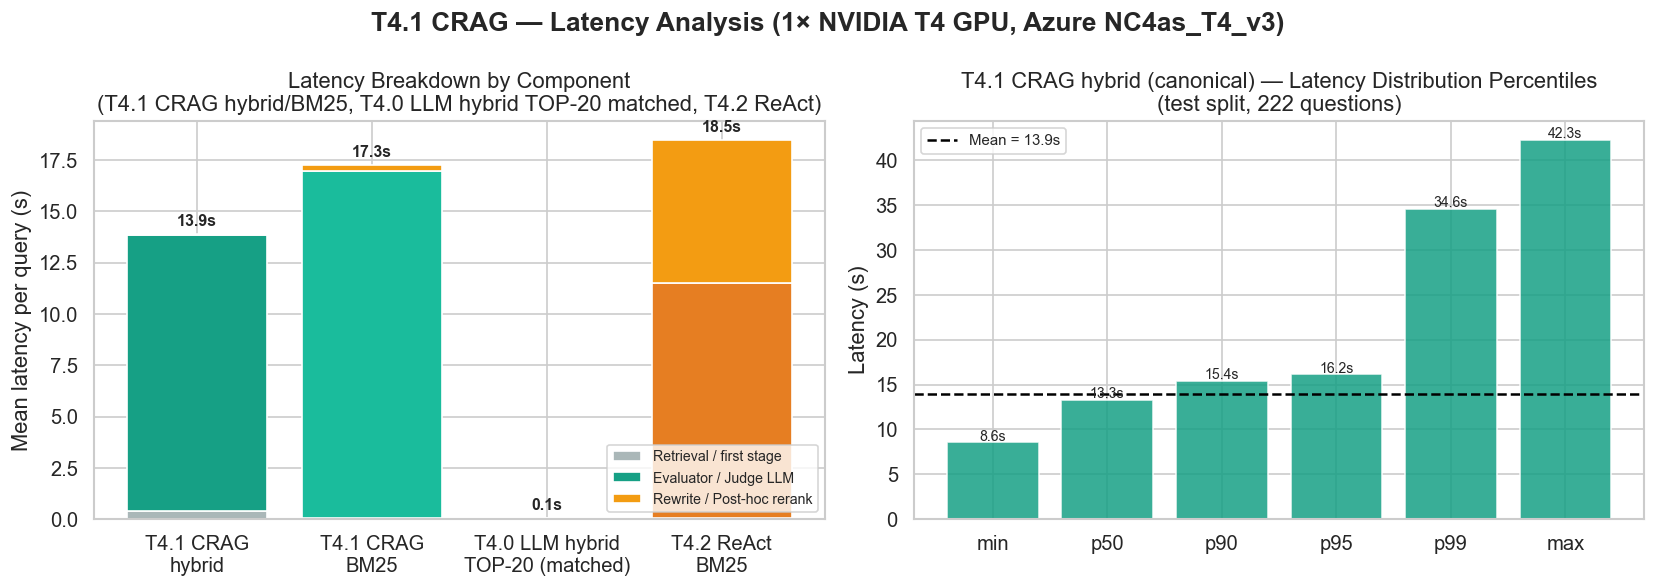


T4.1 CRAG hybrid (canonical):                            mean = 13.9s/query
T4.1 CRAG BM25 (ablation):                                mean = 17.3s/query
T4.0 LLM rerank hybrid TOP-20 (matched pool):             mean = 0.08s/query  (cache-reuse caveat — see T4.0 notebook §5)
T4.2 ReAct BM25:                                          mean = 18.5s/query


In [10]:
# ── Latency breakdown stacked bar ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: stacked bar for agentic + matched T4.0 anchor
ax = axes[0]
crag_hyb_lbd     = crag_hyb_d.get('latency_breakdown_ms_mean', {})
crag_bm25_lbd    = crag_bm25_d.get('latency_breakdown_ms_mean', {})
t40_hyb20_lbd    = t40_hyb20_d.get('latency_breakdown_ms_mean', {})
react_lbd        = react_d.get('latency_breakdown_ms_mean', {})

systems_lat = [
    ('T4.1 CRAG\nhybrid', COLOR_CRAG_HYB,
     crag_hyb_lbd.get('retrieval', 0),
     crag_hyb_lbd.get('evaluator_llm', 0),
     crag_hyb_lbd.get('rewrite_llm', 0)),
    ('T4.1 CRAG\nBM25', COLOR_CRAG_BM25,
     crag_bm25_lbd.get('retrieval', 0),
     crag_bm25_lbd.get('evaluator_llm', 0),
     crag_bm25_lbd.get('rewrite_llm', 0)),
    ('T4.0 LLM hybrid\nTOP-20 (matched)', COLOR_T40_HYB,
     t40_hyb20_lbd.get('first_stage', 0),
     t40_hyb20_lbd.get('llm_scoring', 0), 0),
    ('T4.2 ReAct\nBM25', COLOR_REACT,
     react_lbd.get('retrieval', 0),
     react_lbd.get('llm_generate', 0),
     react_lbd.get('rerank_posthoc', 0)),
]
x_pos    = np.arange(len(systems_lat))
x_labs   = [s[0] for s in systems_lat]
sys_cols = [s[1] for s in systems_lat]
ret_s    = [s[2] / 1000 for s in systems_lat]
eval_s   = [s[3] / 1000 for s in systems_lat]
rw_s     = [s[4] / 1000 for s in systems_lat]

ax.bar(x_pos, ret_s, label='Retrieval / first stage', color='#aab7b8', edgecolor='white')
ax.bar(x_pos, eval_s, bottom=ret_s, label='Evaluator / Judge LLM',
       color=sys_cols, edgecolor='white')
ax.bar(x_pos, rw_s, bottom=[r+e for r,e in zip(ret_s, eval_s)],
       label='Rewrite / Post-hoc rerank', color='#f39c12', edgecolor='white')

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labs)
ax.set_ylabel('Mean latency per query (s)')
ax.set_title('Latency Breakdown by Component\n'
             '(T4.1 CRAG hybrid/BM25, T4.0 LLM hybrid TOP-20 matched, T4.2 ReAct)')
ax.legend(fontsize=8.5)
totals = [r+e+w for r,e,w in zip(ret_s, eval_s, rw_s)]
for xi, total in zip(x_pos, totals):
    ax.text(xi, total + 0.4, f'{total:.1f}s', ha='center', fontsize=9.5, fontweight='bold')

# Right: CRAG hybrid latency distribution (canonical)
ax = axes[1]
dist = crag_hyb_d.get('latency_distribution', {})
p_vals  = [dist.get('min', 0)/1000, dist.get('p50', 0)/1000,
           dist.get('p90', 0)/1000, dist.get('p95', 0)/1000, dist.get('p99', 0)/1000,
           dist.get('max', 0)/1000]
p_labels = ['min', 'p50', 'p90', 'p95', 'p99', 'max']
bars = ax.bar(range(6), p_vals, color=COLOR_CRAG_HYB, edgecolor='white', alpha=0.85)
ax.axhline(dist.get('mean', 0)/1000, color='black', linestyle='--', linewidth=1.5,
           label=f'Mean = {dist.get("mean",0)/1000:.1f}s')
for bar, val in zip(bars, p_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}s', ha='center', fontsize=8.5)
ax.set_xticks(range(6))
ax.set_xticklabels(p_labels)
ax.set_ylabel('Latency (s)')
ax.set_title('T4.1 CRAG hybrid (canonical) — Latency Distribution Percentiles\n(test split, 222 questions)')
ax.legend(fontsize=9)

plt.suptitle('T4.1 CRAG — Latency Analysis (1× NVIDIA T4 GPU, Azure NC4as_T4_v3)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig5_latency.png', bbox_inches='tight')
plt.show()

print(f'\nT4.1 CRAG hybrid (canonical):                            mean = {lat_ms(crag_hyb_d)/1000:.1f}s/query')
print(f'T4.1 CRAG BM25 (ablation):                                mean = {lat_ms(crag_bm25_d)/1000:.1f}s/query')
print(f'T4.0 LLM rerank hybrid TOP-20 (matched pool):             mean = {lat_ms(t40_hyb20_d)/1000:.2f}s/query  '
      f'(cache-reuse caveat — see T4.0 notebook §5)')
print(f'T4.2 ReAct BM25:                                          mean = {lat_ms(react_d)/1000:.1f}s/query')


## 6. Stratified Analysis — CRAG vs Anchors

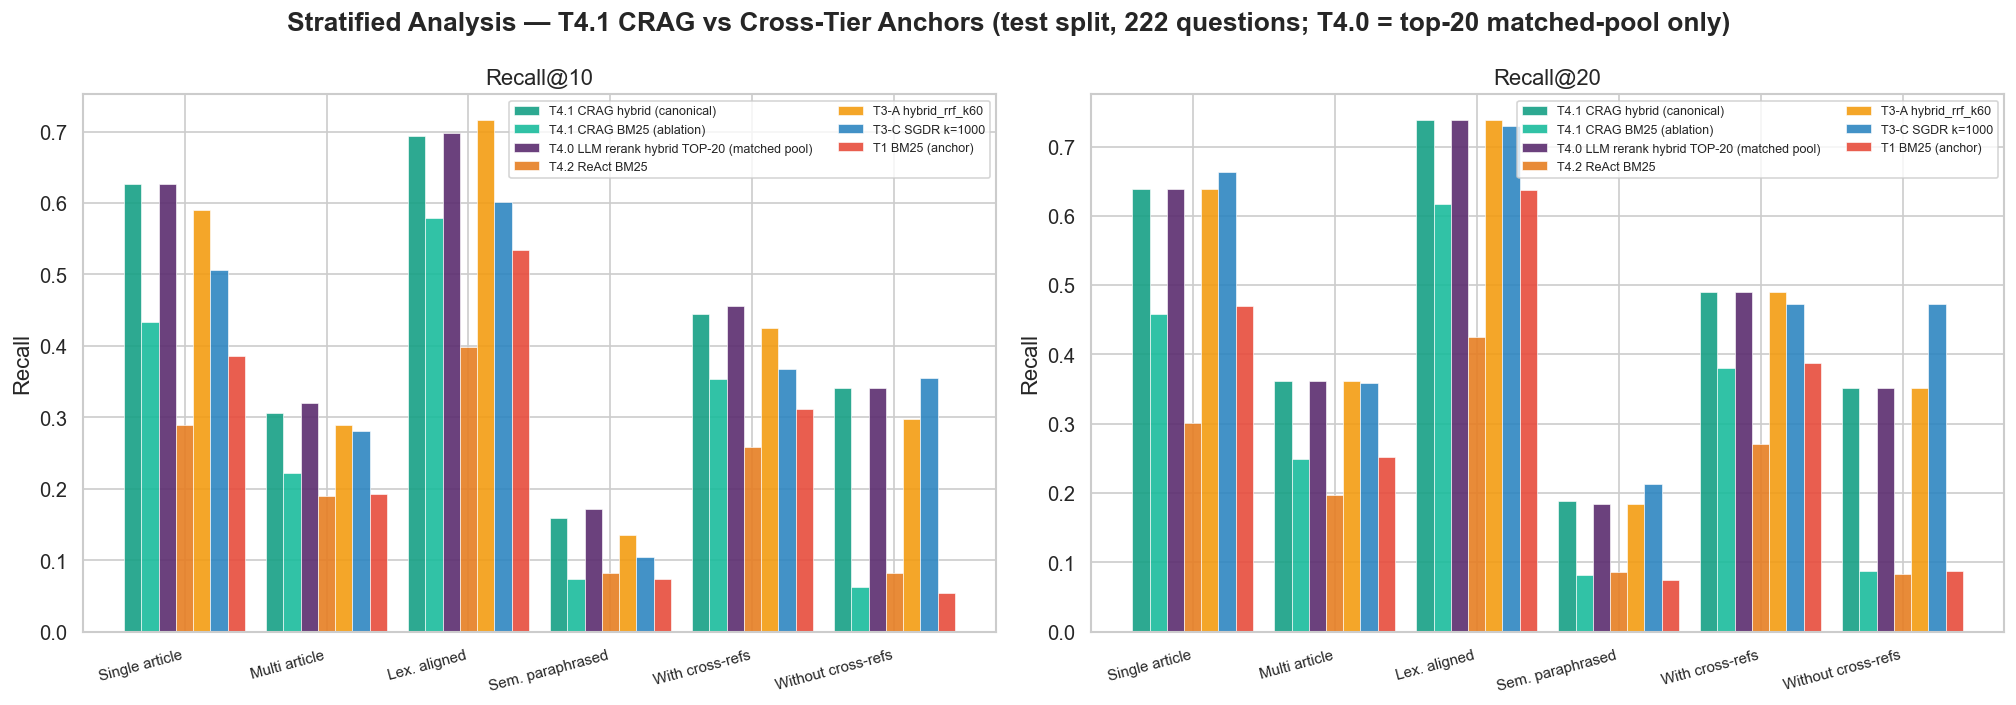

In [11]:
ALL_STRATA = [
    ('single_article',           'Single article'),
    ('multi_article',            'Multi article'),
    ('lexically_aligned',        'Lex. aligned'),
    ('semantically_paraphrased', 'Sem. paraphrased'),
    ('with_cross_refs',          'With cross-refs'),
    ('without_cross_refs',       'Without cross-refs'),
]

# T4.0 row only includes the matched-pool top-20 variant.
systems_strat = [
    ('T4.1 CRAG hybrid (canonical)',                    crag_hyb_d,   COLOR_CRAG_HYB),
    ('T4.1 CRAG BM25 (ablation)',                       crag_bm25_d,  COLOR_CRAG_BM25),
    ('T4.0 LLM rerank hybrid TOP-20 (matched pool)',    t40_hyb20_d,  COLOR_T40_HYB),
    ('T4.2 ReAct BM25',                                 react_d,      COLOR_REACT),
    ('T3-A hybrid_rrf_k60',                             rrf_d,        COLOR_RRF),
    ('T3-C SGDR k=1000',                                sgdr_d,       COLOR_SGDR),
    ('T1 BM25 (anchor)',                                bm25_d,       COLOR_BM25),
]

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
# R@k > eval_k=20 is meaningless for CRAG (only the top-20 are judged) →
# show R@10 and R@20 instead of R@10 and R@100.
for ax, metric in zip(axes, ['Recall@10', 'Recall@20']):
    x     = np.arange(len(ALL_STRATA))
    n     = len(systems_strat)
    width = 0.85 / n
    for i, (label, d, color) in enumerate(systems_strat):
        vals = [d['stratified'].get(s, {}).get(metric, 0) for s, _ in ALL_STRATA]
        offset = (i - n/2 + 0.5) * width
        ax.bar(x + offset, vals, width, label=label, color=color,
               edgecolor='white', linewidth=0.4, alpha=0.9)

    ax.set_xticks(x)
    ax.set_xticklabels([lbl for _, lbl in ALL_STRATA], rotation=15, ha='right', fontsize=9)
    ax.set_title(metric)
    ax.set_ylabel('Recall')
    ax.legend(fontsize=7.5, ncol=2)

plt.suptitle('Stratified Analysis — T4.1 CRAG vs Cross-Tier Anchors '
             '(test split, 222 questions; T4.0 = top-20 matched-pool only)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig6_stratified.png', bbox_inches='tight')
plt.show()


In [12]:
# ── Strata numeric table ────────────────────────────────────────────────────
strat_rows = []
for stratum, label in ALL_STRATA:
    row = {'Stratum': label}
    for sys_label, d, _ in systems_strat:
        sm = d['stratified'].get(stratum, {})
        row[f'{sys_label} R@10'] = sm.get('Recall@10', 0)
        row[f'{sys_label} R@20'] = sm.get('Recall@20', 0)  # cap at eval_k=20
    strat_rows.append(row)

strat_df = pd.DataFrame(strat_rows)
fmt_s = {c: '{:.4f}' for c in strat_df.columns if c != 'Stratum'}
display(strat_df.style.format(fmt_s).hide(axis='index'))

print('\nLexical vs Semantic gap (R@10):')
for sys_label, d, _ in systems_strat:
    lex = d['stratified'].get('lexically_aligned', {}).get('Recall@10', 0)
    sem = d['stratified'].get('semantically_paraphrased', {}).get('Recall@10', 0)
    print(f'  {sys_label:<35} lex={lex:.4f}  sem={sem:.4f}  gap={lex-sem:+.4f}')


Stratum,T4.1 CRAG hybrid (canonical) R@10,T4.1 CRAG hybrid (canonical) R@20,T4.1 CRAG BM25 (ablation) R@10,T4.1 CRAG BM25 (ablation) R@20,T4.0 LLM rerank hybrid TOP-20 (matched pool) R@10,T4.0 LLM rerank hybrid TOP-20 (matched pool) R@20,T4.2 ReAct BM25 R@10,T4.2 ReAct BM25 R@20,T3-A hybrid_rrf_k60 R@10,T3-A hybrid_rrf_k60 R@20,T3-C SGDR k=1000 R@10,T3-C SGDR k=1000 R@20,T1 BM25 (anchor) R@10,T1 BM25 (anchor) R@20
Single article,0.6265,0.6386,0.4337,0.4578,0.6265,0.6386,0.2892,0.3012,0.5904,0.6386,0.5060,0.6627,0.3855,0.4699
Multi article,0.3068,0.3618,0.2220,0.2490,0.3201,0.3610,0.1893,0.1976,0.2896,0.3610,0.2815,0.3588,0.1932,0.2519
Lex. aligned,0.6943,0.7384,0.5797,0.6168,0.6980,0.7384,0.3981,0.4249,0.7164,0.7384,0.6011,0.7290,0.5346,0.6379
Sem. paraphrased,0.1595,0.1887,0.0744,0.0812,0.1719,0.1839,0.0828,0.0862,0.1349,0.1839,0.1045,0.2133,0.0743,0.0750
With cross-refs,0.4450,0.4902,0.3536,0.3797,0.4552,0.4896,0.2583,0.2701,0.4251,0.4896,0.3677,0.4723,0.3114,0.3874
Without cross-refs,0.3411,0.3517,0.0626,0.0876,0.3411,0.3517,0.0826,0.0826,0.2971,0.3517,0.3551,0.4726,0.0542,0.0876



Lexical vs Semantic gap (R@10):
  T4.1 CRAG hybrid (canonical)        lex=0.6943  sem=0.1595  gap=+0.5348
  T4.1 CRAG BM25 (ablation)           lex=0.5797  sem=0.0744  gap=+0.5053
  T4.0 LLM rerank hybrid TOP-20 (matched pool) lex=0.6980  sem=0.1719  gap=+0.5261
  T4.2 ReAct BM25                     lex=0.3981  sem=0.0828  gap=+0.3154
  T3-A hybrid_rrf_k60                 lex=0.7164  sem=0.1349  gap=+0.5815
  T3-C SGDR k=1000                    lex=0.6011  sem=0.1045  gap=+0.4967
  T1 BM25 (anchor)                    lex=0.5346  sem=0.0743  gap=+0.4603


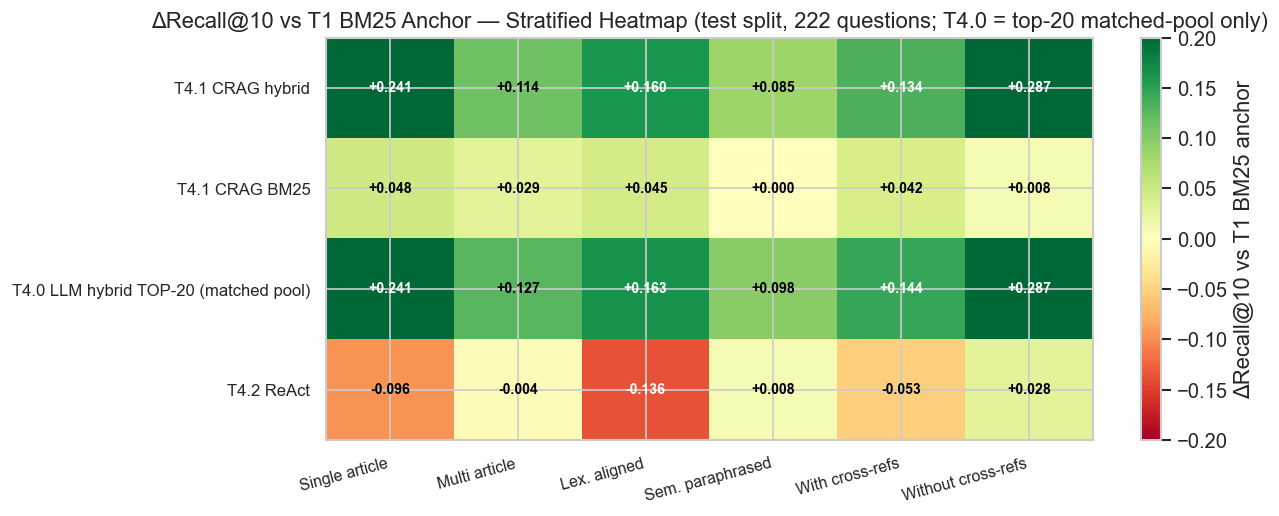

In [13]:
# ── Stratified heatmap — system Δ vs T1 BM25 anchor ────────────────────────
strata_names = [lbl for _, lbl in ALL_STRATA]
strata_keys  = [s for s, _ in ALL_STRATA]

# T4.0 row only includes the matched-pool top-20 variant (capped at R@10 — the
# pool size argument applies to R@20 as well, but R@10 is the primary axis here).
compare_systems = [
    ('T4.1 CRAG hybrid',                          crag_hyb_d),
    ('T4.1 CRAG BM25',                            crag_bm25_d),
    ('T4.0 LLM hybrid TOP-20 (matched pool)',     t40_hyb20_d),
    ('T4.2 ReAct',                                react_d),
]

delta_matrix = np.array([
    [d['stratified'].get(s, {}).get('Recall@10', 0) - bm25_d['stratified'].get(s, {}).get('Recall@10', 0)
     for s in strata_keys]
    for _, d in compare_systems
])

fig, ax = plt.subplots(figsize=(11, 4.5))
im = ax.imshow(delta_matrix, aspect='auto', cmap='RdYlGn',
               vmin=-0.20, vmax=0.20)
plt.colorbar(im, ax=ax, label='ΔRecall@10 vs T1 BM25 anchor')
ax.set_xticks(range(len(strata_names)))
ax.set_xticklabels(strata_names, rotation=15, ha='right', fontsize=9.5)
ax.set_yticks(range(len(compare_systems)))
ax.set_yticklabels([s[0] for s in compare_systems], fontsize=10)

for i in range(len(compare_systems)):
    for j in range(len(strata_keys)):
        ax.text(j, i, f'{delta_matrix[i, j]:+.3f}', ha='center', va='center',
                fontsize=8.5, fontweight='bold',
                color='white' if abs(delta_matrix[i, j]) > 0.13 else 'black')

ax.set_title('ΔRecall@10 vs T1 BM25 Anchor — Stratified Heatmap '
             '(test split, 222 questions; T4.0 = top-20 matched-pool only)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig7_stratified_delta_heatmap.png', bbox_inches='tight')
plt.show()


## 7. Delta Analysis — CRAG vs All Reference Points

In [14]:
# CRAG eval_k=20 → cap displayed metrics at R@20.
# T4.0 comparison restricted to the matched-pool top-20 variant.
comp_metrics = ['Recall@1', 'Recall@5', 'Recall@10', 'Recall@20', 'MRR@10', 'NDCG@10']

PRIMARY = crag_hyb_d
PRIMARY_LABEL = 'T4.1 CRAG hybrid (canonical)'

refs = [
    ('vs T3-A hybrid_rrf_k60 (canonical anchor)',          rrf_d,        COLOR_RRF),
    ('vs T4.1 CRAG BM25 (pool quality)',                   crag_bm25_d,  COLOR_CRAG_BM25),
    ('vs T4.0 LLM hybrid TOP-20 (matched-pool anchor)',    t40_hyb20_d,  COLOR_T40_HYB),
    ('vs T1 BM25 anchor',                                  bm25_d,       COLOR_BM25),
    ('vs T3-C SGDR k=1000',                                sgdr_d,       COLOR_SGDR),
    ('vs T4.2 ReAct BM25',                                 react_d,      COLOR_REACT),
]

delta_rows = []
for met in comp_metrics:
    row = {'Metric': met, PRIMARY_LABEL: m(PRIMARY).get(met, 0)}
    for label, ref_d, _ in refs:
        row[f'Δ {label}'] = m(PRIMARY).get(met, 0) - m(ref_d).get(met, 0)
    delta_rows.append(row)

delta_df = pd.DataFrame(delta_rows)
delta_cols = [c for c in delta_df.columns if c.startswith('Δ')]
fmt_delta  = {c: '{:+.4f}' for c in delta_cols}
fmt_delta[PRIMARY_LABEL] = '{:.4f}'
display(delta_df.style.format(fmt_delta).hide(axis='index')
        .bar(subset=delta_cols, align='zero', color=['#e74c3c', '#27ae60']))

print('\nKey deltas at R@10:')
for label, ref_d, _ in refs:
    delta = r10(PRIMARY) - r10(ref_d)
    arrow = '▲' if delta > 0 else ('▼' if delta < 0 else '=')
    print(f'  T4.1 CRAG hybrid {label:<55}: {delta:+.4f} {arrow}')


Metric,T4.1 CRAG hybrid (canonical),Δ vs T3-A hybrid_rrf_k60 (canonical anchor),Δ vs T4.1 CRAG BM25 (pool quality),Δ vs T4.0 LLM hybrid TOP-20 (matched-pool anchor),Δ vs T1 BM25 anchor,Δ vs T3-C SGDR k=1000,Δ vs T4.2 ReAct BM25
Recall@1,0.1365,+0.0222,+0.0090,+0.0009,+0.0247,+0.0387,+0.0786
Recall@5,0.3520,+0.0611,+0.1016,-0.0114,+0.1500,+0.0921,+0.1737
Recall@10,0.4263,+0.0242,+0.1251,-0.0083,+0.1612,+0.0609,+0.1997
Recall@20,0.4653,+0.0005,+0.1382,+0.0005,+0.1319,-0.0071,+0.2289
MRR@10,0.3938,+0.0536,+0.0616,-0.0001,+0.1427,+0.0667,+0.1737
NDCG@10,0.3461,+0.0367,+0.0809,-0.0055,+0.1240,+0.0610,+0.1627



Key deltas at R@10:
  T4.1 CRAG hybrid vs T3-A hybrid_rrf_k60 (canonical anchor)              : +0.0242 ▲
  T4.1 CRAG hybrid vs T4.1 CRAG BM25 (pool quality)                       : +0.1251 ▲
  T4.1 CRAG hybrid vs T4.0 LLM hybrid TOP-20 (matched-pool anchor)        : -0.0083 ▼
  T4.1 CRAG hybrid vs T1 BM25 anchor                                      : +0.1612 ▲
  T4.1 CRAG hybrid vs T3-C SGDR k=1000                                    : +0.0609 ▲
  T4.1 CRAG hybrid vs T4.2 ReAct BM25                                     : +0.1997 ▲


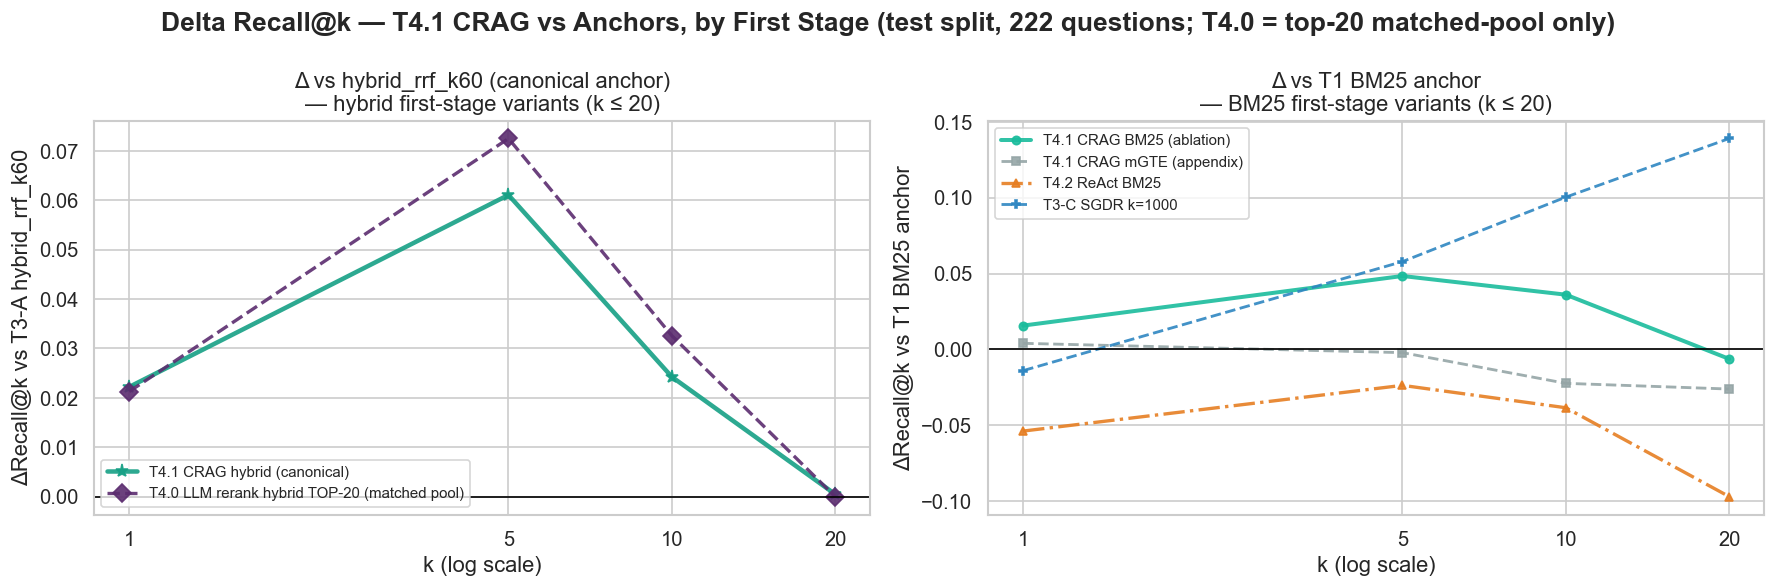

In [15]:
# ── ΔRecall@k curves: hybrid-stage panel + BM25-stage panel ───────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left panel: vs T3-A hybrid_rrf_k60 (canonical anchor) — hybrid first stage
ax = axes[0]
delta_hyb_systems = [
    (crag_hyb_d,  'T4.1 CRAG hybrid (canonical)',                       COLOR_CRAG_HYB, '-', '*', 2.7),
    (t40_hyb20_d, 'T4.0 LLM rerank hybrid TOP-20 (matched pool)',       COLOR_T40_HYB,  '--','D', 2.0),
]
for d, label, color, ls, marker, lw in delta_hyb_systems:
    deltas = [m(d).get(f'Recall@{k}', 0) - m(rrf_d).get(f'Recall@{k}', 0)
              for k in K_VALS]
    ax.plot(K_VALS, deltas, label=label, color=color, linewidth=lw,
            linestyle=ls, marker=marker, markersize=8, alpha=0.9)
ax.axhline(0, color='black', linewidth=1.0)
ax.set_xscale('log')
ax.set_xlabel('k (log scale)')
ax.set_ylabel('ΔRecall@k vs T3-A hybrid_rrf_k60')
ax.set_title('Δ vs hybrid_rrf_k60 (canonical anchor)\n— hybrid first-stage variants (k ≤ 20)')
ax.set_xticks(K_VALS); ax.set_xticklabels(K_VALS)
ax.legend(fontsize=9, loc='lower left')

# Right panel: BM25-first-stage variants vs T1 BM25 anchor (no T4.0-BM25 — its
# top-50 variant is excluded under the apples-to-apples convention).
ax = axes[1]
delta_bm25_systems = [
    (crag_bm25_d, 'T4.1 CRAG BM25 (ablation)', COLOR_CRAG_BM25, '-',  'o', 2.4),
    (crag_mgte_d, 'T4.1 CRAG mGTE (appendix)', COLOR_CRAG_M,    '--', 's', 1.7),
    (react_d,     'T4.2 ReAct BM25',           COLOR_REACT,     '-.', '^', 2.0),
    (sgdr_d,      'T3-C SGDR k=1000',          COLOR_SGDR,      '--', 'P', 1.7),
]
for d, label, color, ls, marker, lw in delta_bm25_systems:
    deltas = [m(d).get(f'Recall@{k}', 0) - m(bm25_d).get(f'Recall@{k}', 0)
              for k in K_VALS]
    ax.plot(K_VALS, deltas, label=label, color=color, linewidth=lw,
            linestyle=ls, marker=marker, markersize=5, alpha=0.9)

ax.axhline(0, color='black', linewidth=1.0)
ax.set_xscale('log')
ax.set_xlabel('k (log scale)')
ax.set_ylabel('ΔRecall@k vs T1 BM25 anchor')
ax.set_title('Δ vs T1 BM25 anchor\n— BM25 first-stage variants (k ≤ 20)')
ax.set_xticks(K_VALS); ax.set_xticklabels(K_VALS)
ax.legend(fontsize=9)

plt.suptitle('Delta Recall@k — T4.1 CRAG vs Anchors, by First Stage '
             '(test split, 222 questions; T4.0 = top-20 matched-pool only)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig8_delta_recall_k.png', bbox_inches='tight')
plt.show()


## 8. Significance Tests — Three-Way for Canonical Hybrid Run

The hybrid CRAG result JSON ships with pre-computed significance fields:
- `significance_vs_anchor` → vs T3-A hybrid_rrf_k60 (CRAG loop value on hybrid pool, **PRIMARY**).
- `secondary_significance.vs_crag_bm25_test_v2` → vs T4.1 CRAG BM25 (pool quality, same loop).
- `secondary_significance.vs_llm_rerank_binary_top50_hybrid_rrf_k60_test` → vs T4.0 LLM rerank hybrid (agentic value, same hybrid pool).

All p-values come from a paired t-test on per-query Recall@10, computed with the per-query Recall
helper from `bsard_evaluation` against the `_trec_run` / `_trec_qrels` fields.


In [16]:
# ── Significance results loaded from hybrid CRAG result JSON ───────────────
# T4.0 comparison restricted to the matched-pool top-20 variant. The result JSON
# only ships pre-computed significance vs T4.0-hybrid-top50; the top-20 test is
# computed live below using per-query Recall@10 from the trec_run/trec_qrels.
import sys as _sys
from scipy.stats import ttest_rel
if str(ROOT) not in _sys.path:
    _sys.path.insert(0, str(ROOT))
try:
    from bsard_evaluation import per_query_recall as _bsard_per_query_recall
except Exception:
    _bsard_per_query_recall = None

sig_pri  = crag_hyb_d.get('significance_vs_anchor', {})  # vs T3-A hybrid_rrf_k60
sec      = crag_hyb_d.get('secondary_significance', {})
sig_pool = sec.get('vs_crag_bm25_test_v2', {})            # pool quality

# Live paired t-test: CRAG hybrid vs T4.0 hybrid top-20 (matched pool)
sig_agnt_top20 = {'p_value_recall10': None, 'significant': None,
                  'anchor_experiment_id': 'llm_rerank_binary_top20_hybrid_rrf_k60_test'}
if (_bsard_per_query_recall is not None
        and '_trec_run' in crag_hyb_d and '_trec_qrels' in crag_hyb_d
        and '_trec_run' in t40_hyb20_d and '_trec_qrels' in t40_hyb20_d):
    r_crag10 = _bsard_per_query_recall(crag_hyb_d['_trec_qrels'], crag_hyb_d['_trec_run'], 10)
    r_t4020  = _bsard_per_query_recall(t40_hyb20_d['_trec_qrels'], t40_hyb20_d['_trec_run'], 10)
    if r_crag10 is not None and r_t4020 is not None:
        _, p10 = ttest_rel(r_crag10, r_t4020)
        sig_agnt_top20['p_value_recall10'] = float(p10)
        sig_agnt_top20['significant'] = bool(p10 < 0.05)

print('Significance tests for T4.1 CRAG hybrid (canonical):')
print('  PRIMARY      (vs T3-A hybrid_rrf_k60)              : '
      f'p(R@10)={sig_pri.get("p_value_recall10", float("nan")):.4f}  '
      f'→ {"SIGNIFICANT" if sig_pri.get("significant") else "not significant"}')
print('  POOL QUALITY (vs T4.1 CRAG BM25 ablation)          : '
      f'p(R@10)={sig_pool.get("p_value_recall10", float("nan")):.4f}  '
      f'→ {"SIGNIFICANT" if sig_pool.get("significant") else "not significant"}')
print('  AGENTIC VAL  (vs T4.0 hybrid TOP-20, matched pool) : '
      f'p(R@10)={sig_agnt_top20.get("p_value_recall10") or float("nan"):.4f}  '
      f'→ {"SIGNIFICANT" if sig_agnt_top20.get("significant") else "not significant"}')
print()

sig_rows = [
    {
        'Comparison':  'T4.1 CRAG hybrid  vs  T3-A hybrid_rrf_k60       [PRIMARY]',
        'CRAG R@10':   r10(crag_hyb_d),
        'Anchor R@10': r10(rrf_d),
        'Δ R@10':      r10(crag_hyb_d) - r10(rrf_d),
        'p (R@10)':    sig_pri.get('p_value_recall10'),
        'Significant': sig_pri.get('significant'),
        'Interpretation': 'CRAG loop value on hybrid pool',
    },
    {
        'Comparison':  'T4.1 CRAG hybrid  vs  T4.1 CRAG BM25            [POOL QUALITY]',
        'CRAG R@10':   r10(crag_hyb_d),
        'Anchor R@10': r10(crag_bm25_d),
        'Δ R@10':      r10(crag_hyb_d) - r10(crag_bm25_d),
        'p (R@10)':    sig_pool.get('p_value_recall10'),
        'Significant': sig_pool.get('significant'),
        'Interpretation': 'Pool quality effect (same CRAG loop)',
    },
    {
        'Comparison':  'T4.1 CRAG hybrid  vs  T4.0 hybrid TOP-20 (matched pool) [AGENTIC VALUE]',
        'CRAG R@10':   r10(crag_hyb_d),
        'Anchor R@10': r10(t40_hyb20_d),
        'Δ R@10':      r10(crag_hyb_d) - r10(t40_hyb20_d),
        'p (R@10)':    sig_agnt_top20.get('p_value_recall10'),
        'Significant': sig_agnt_top20.get('significant'),
        'Interpretation': 'CRAG vs LLM rerank, IDENTICAL hybrid candidate pool',
    },
]

sig_df = pd.DataFrame(sig_rows)
display(sig_df.style.format({
    'CRAG R@10': '{:.4f}', 'Anchor R@10': '{:.4f}',
    'Δ R@10':    '{:+.4f}', 'p (R@10)':   '{:.4f}',
}, na_rep='—').hide(axis='index'))

# ── Aggregate Δ for BM25-stage CRAG vs T1 BM25 anchor (no per-query test stored) ──
print('\n── Reference deltas for the BM25 ablation (aggregate-only) ──')
print(f'  T4.1 CRAG BM25  vs  T1 BM25 anchor : '
      f'Δ R@10 = {r10(crag_bm25_d) - r10(bm25_d):+.4f}  '
      f'(per-query test not pre-computed for this pair)')
print(f'  T4.1 CRAG BM25  vs  T4.2 ReAct BM25 : '
      f'Δ R@10 = {r10(crag_bm25_d) - r10(react_d):+.4f}')


Significance tests for T4.1 CRAG hybrid (canonical):
  PRIMARY      (vs T3-A hybrid_rrf_k60)              : p(R@10)=0.0463  → SIGNIFICANT
  POOL QUALITY (vs T4.1 CRAG BM25 ablation)          : p(R@10)=0.0000  → SIGNIFICANT
  AGENTIC VAL  (vs T4.0 hybrid TOP-20, matched pool) : p(R@10)=nan  → not significant



Comparison,CRAG R@10,Anchor R@10,Δ R@10,p (R@10),Significant,Interpretation
T4.1 CRAG hybrid vs T3-A hybrid_rrf_k60 [PRIMARY],0.4263,0.4021,+0.0242,0.0463,True,CRAG loop value on hybrid pool
T4.1 CRAG hybrid vs T4.1 CRAG BM25 [POOL QUALITY],0.4263,0.3012,+0.1251,0.0000,True,Pool quality effect (same CRAG loop)
T4.1 CRAG hybrid vs T4.0 hybrid TOP-20 (matched pool) [AGENTIC VALUE],0.4263,0.4347,-0.0083,—,—,"CRAG vs LLM rerank, IDENTICAL hybrid candidate pool"



── Reference deltas for the BM25 ablation (aggregate-only) ──
  T4.1 CRAG BM25  vs  T1 BM25 anchor : Δ R@10 = +0.0361  (per-query test not pre-computed for this pair)
  T4.1 CRAG BM25  vs  T4.2 ReAct BM25 : Δ R@10 = +0.0745


## 9. Pareto Front — Latency vs Recall@10 Across All Tiers

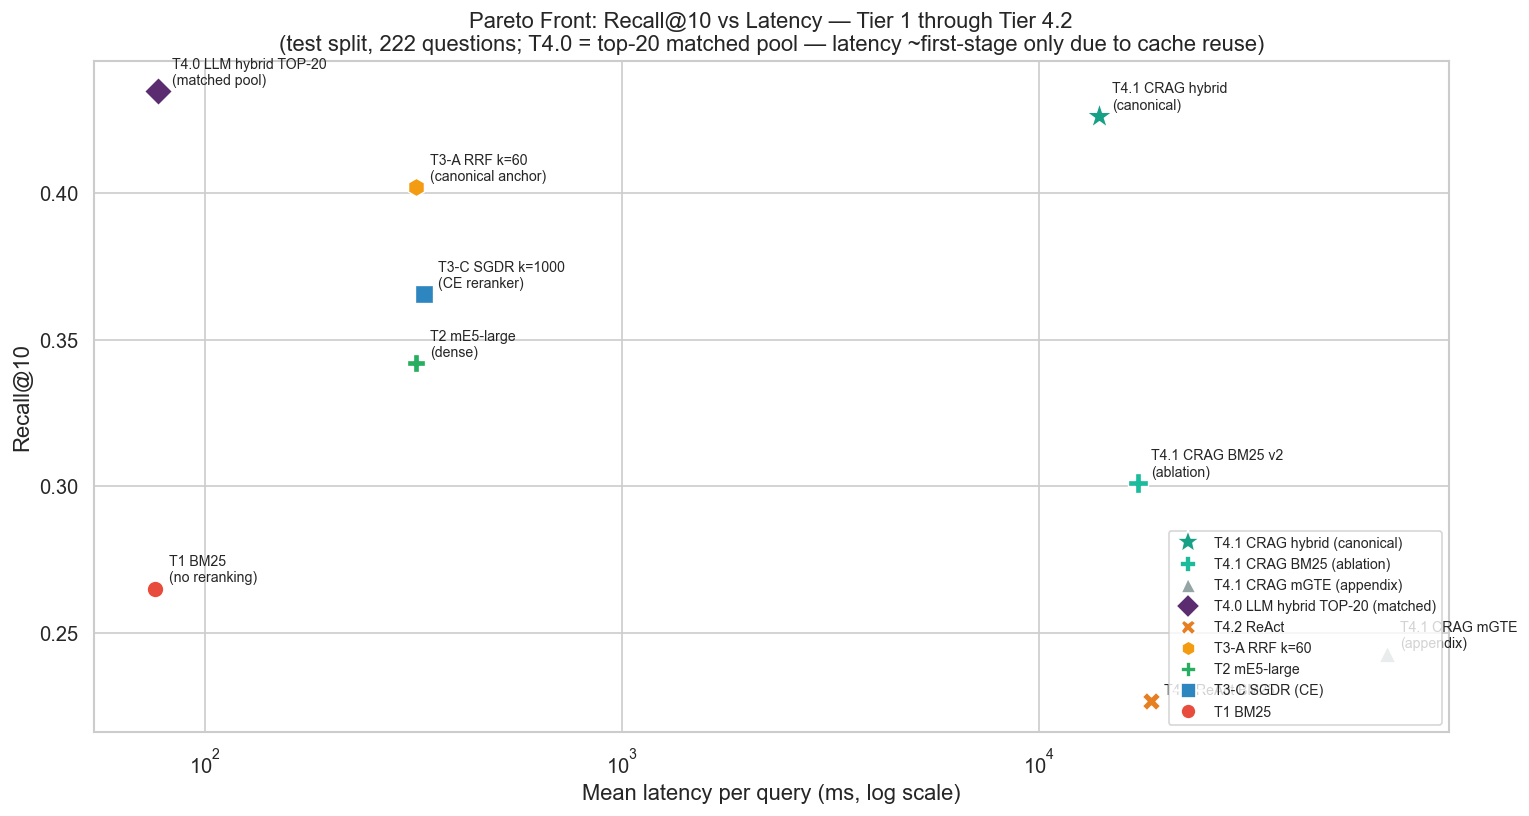

In [17]:
# dense_d already loaded at top
# T4.0 row only includes the matched-pool top-20 variant.
pareto_systems = [
    ('T1 BM25\n(no reranking)',                          bm25_d,      COLOR_BM25,      'o', 100),
    ('T3-C SGDR k=1000\n(CE reranker)',                  sgdr_d,      COLOR_SGDR,      's', 120),
    ('T3-A RRF k=60\n(canonical anchor)',                rrf_d,       COLOR_RRF,       'h', 120),
    ('T4.0 LLM hybrid TOP-20\n(matched pool)',           t40_hyb20_d, COLOR_T40_HYB,   'D', 140),
    ('T4.1 CRAG hybrid\n(canonical)',                    crag_hyb_d,  COLOR_CRAG_HYB,  '*', 260),
    ('T4.1 CRAG BM25 v2\n(ablation)',                    crag_bm25_d, COLOR_CRAG_BM25, 'P', 140),
    ('T4.1 CRAG mGTE\n(appendix)',                       crag_mgte_d, COLOR_CRAG_M,    '^', 100),
    ('T4.2 ReAct BM25',                                   react_d,     COLOR_REACT,     'X', 120),
]
if dense_d:
    pareto_systems.insert(2, ('T2 mE5-large\n(dense)', dense_d, COLOR_DENSE, 'P', 110))

fig, ax = plt.subplots(figsize=(13, 7))
for label, d, color, marker, sz in pareto_systems:
    lat_v    = lat_ms(d)
    recall10 = r10(d)
    ax.scatter(lat_v, recall10, color=color, s=sz, marker=marker, zorder=4,
               edgecolors='white', linewidth=0.8)
    ax.annotate(label, (lat_v, recall10),
                textcoords='offset points', xytext=(8, 4), fontsize=8.5)

ax.set_xscale('log')
ax.set_xlabel('Mean latency per query (ms, log scale)')
ax.set_ylabel('Recall@10')
ax.set_title('Pareto Front: Recall@10 vs Latency — Tier 1 through Tier 4.2\n'
             '(test split, 222 questions; T4.0 = top-20 matched pool — '
             'latency ~first-stage only due to cache reuse)')

legend_items = [
    plt.Line2D([0],[0], marker='*', color='w', markerfacecolor=COLOR_CRAG_HYB,  markersize=15, label='T4.1 CRAG hybrid (canonical)'),
    plt.Line2D([0],[0], marker='P', color='w', markerfacecolor=COLOR_CRAG_BM25, markersize=10, label='T4.1 CRAG BM25 (ablation)'),
    plt.Line2D([0],[0], marker='^', color='w', markerfacecolor=COLOR_CRAG_M,    markersize=9,  label='T4.1 CRAG mGTE (appendix)'),
    plt.Line2D([0],[0], marker='D', color='w', markerfacecolor=COLOR_T40_HYB,   markersize=10, label='T4.0 LLM hybrid TOP-20 (matched)'),
    plt.Line2D([0],[0], marker='X', color='w', markerfacecolor=COLOR_REACT,     markersize=9,  label='T4.2 ReAct'),
    plt.Line2D([0],[0], marker='h', color='w', markerfacecolor=COLOR_RRF,       markersize=9,  label='T3-A RRF k=60'),
    plt.Line2D([0],[0], marker='s', color='w', markerfacecolor=COLOR_SGDR,      markersize=9,  label='T3-C SGDR (CE)'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=COLOR_BM25,      markersize=9,  label='T1 BM25'),
]
if dense_d:
    legend_items.insert(6, plt.Line2D([0],[0], marker='P', color='w',
                                       markerfacecolor=COLOR_DENSE, markersize=9, label='T2 mE5-large'))

ax.legend(handles=legend_items, fontsize=8.5, loc='lower right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig9_pareto_front.png', bbox_inches='tight')
plt.show()


## 10. Evaluator Calibration — LLaMA Collective vs mGTE Cross-Encoder

Comparison of evaluator behaviour using the CRAG loop as a probe. Both BM25 and hybrid first
stages used the same LLaMA evaluator; the hybrid pool yields a higher Correct first-pass rate,
showing the evaluator's behaviour is partially driven by candidate pool quality.

The mGTE cross-encoder calibration data is from `crag_evaluator_accuracy.json`.


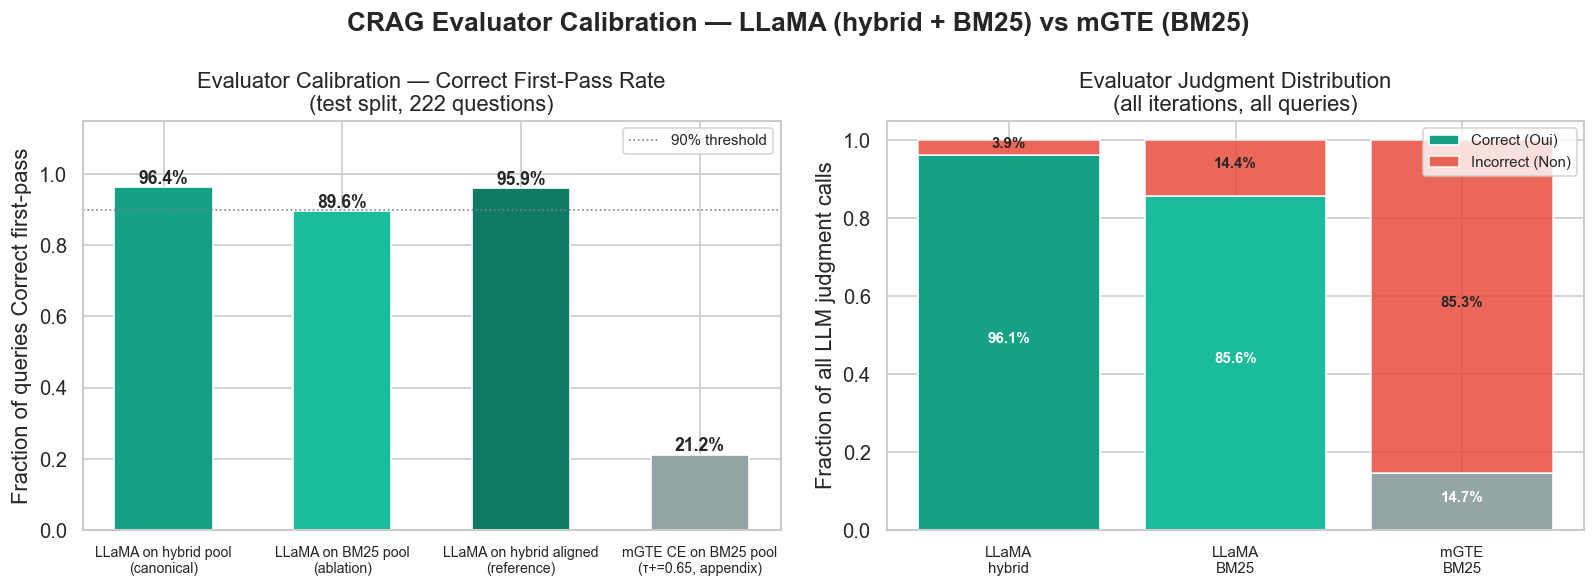


mGTE evaluator accuracy (from crag_evaluator_accuracy.json):
  Overall accuracy: 0.6543
  Correct class  — precision: 0.7101  recall: 0.8596
  Incorrect class — precision: 0.3333  recall: 0.1667
  Confusion matrix (GT rows, pred cols): [[49, 8], [20, 4]]


In [18]:
eval_acc_path = CRAG_DIR / 'crag_evaluator_accuracy.json'
eval_acc = json.loads(eval_acc_path.read_text()) if eval_acc_path.exists() else {}

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))

# Left: Correct first-pass rate comparison (across evaluators × first stages)
ax = axes[0]
systems_eval = [
    ('LLaMA on hybrid pool\n(canonical)',
     loop_hyb['fraction_queries_correct_first_pass'],   COLOR_CRAG_HYB),
    ('LLaMA on BM25 pool\n(ablation)',
     loop_v2['fraction_queries_correct_first_pass'],    COLOR_CRAG_BM25),
    ('LLaMA on hybrid aligned\n(reference)',
     loop_alig['fraction_queries_correct_first_pass'],  COLOR_ALIGNED),
    ('mGTE CE on BM25 pool\n(τ+=0.65, appendix)',
     loop_mgt['fraction_queries_correct_first_pass'],   COLOR_CRAG_M),
]
lbls_ = [s[0] for s in systems_eval]
vals_ = [s[1] for s in systems_eval]
cols_ = [s[2] for s in systems_eval]
bars  = ax.bar(range(len(systems_eval)), vals_, color=cols_, edgecolor='white', width=0.55)
for bar, val in zip(bars, vals_):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', fontsize=10.5, fontweight='bold')
ax.set_xticks(range(len(systems_eval)))
ax.set_xticklabels(lbls_, fontsize=8.5)
ax.set_ylabel('Fraction of queries Correct first-pass')
ax.set_title('Evaluator Calibration — Correct First-Pass Rate\n(test split, 222 questions)')
ax.set_ylim(0, 1.15)
ax.axhline(0.90, color='gray', linestyle=':', linewidth=1, label='90% threshold')
ax.legend(fontsize=9)

# Right: Distribution of Correct vs Incorrect judgments (all iterations)
ax = axes[1]
systems_dist = [
    ('LLaMA\nhybrid', loop_hyb, COLOR_CRAG_HYB),
    ('LLaMA\nBM25',   loop_v2,  COLOR_CRAG_BM25),
    ('mGTE\nBM25',    loop_mgt, COLOR_CRAG_M),
]
x = np.arange(len(systems_dist))
correct_frac   = [s[1]['distribution_Correct']   for s in systems_dist]
incorrect_frac = [s[1]['distribution_Incorrect'] for s in systems_dist]
sys_cols = [s[2] for s in systems_dist]
ax.bar(x, correct_frac,   label='Correct (Oui)',   color=sys_cols, edgecolor='white')
ax.bar(x, incorrect_frac, bottom=correct_frac,
       label='Incorrect (Non)', color='#e74c3c', edgecolor='white', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([s[0] for s in systems_dist], fontsize=9)
ax.set_ylabel('Fraction of all LLM judgment calls')
ax.set_title('Evaluator Judgment Distribution\n(all iterations, all queries)')
ax.legend(fontsize=9)
for xi, (c, i) in enumerate(zip(correct_frac, incorrect_frac)):
    ax.text(xi, c/2, f'{c:.1%}', ha='center', fontsize=9, fontweight='bold', color='white')
    ax.text(xi, c + i/2, f'{i:.1%}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('CRAG Evaluator Calibration — LLaMA (hybrid + BM25) vs mGTE (BM25)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig10_evaluator_calibration.png', bbox_inches='tight')
plt.show()

if eval_acc:
    print('\nmGTE evaluator accuracy (from crag_evaluator_accuracy.json):')
    ce = eval_acc.get('ce_accuracy', {})
    print(f'  Overall accuracy: {ce.get("overall_accuracy", 0):.4f}')
    per_cls = ce.get('per_class', {})
    print(f'  Correct class  — precision: {per_cls.get("Correct",{}).get("precision",0):.4f}  '
          f'recall: {per_cls.get("Correct",{}).get("recall",0):.4f}')
    print(f'  Incorrect class — precision: {per_cls.get("Incorrect",{}).get("precision",0):.4f}  '
          f'recall: {per_cls.get("Incorrect",{}).get("recall",0):.4f}')
    cm = ce.get('confusion_matrix', [[0,0],[0,0]])
    print(f'  Confusion matrix (GT rows, pred cols): {cm}')


## 11. Summary of Key Findings

> **Reporting note.** This notebook caps all displayed recall metrics at `eval_k = 20`. CRAG only
> judges the top-20 candidates per iteration, so Recall@k for k > 20 is the first-stage retriever
> passing through and does not reflect the CRAG loop's contribution. Anchor systems (T3-A, T1 BM25)
> have meaningful Recall@100 — see their respective tier notebooks.
>
> **T4.0 comparison restricted to the top-20 variant.** All cross-tier comparisons involving T4.0
> use only the `llm_rerank_binary_top20_hybrid_rrf_k60_test` run (R@10 = 0.4347), which has the
> same candidate-pool size as CRAG (eval_k = 20). The T4.0 top-50 variants (BM25 and hybrid) use
> a different pool size (top_n = 50) and are excluded here — they are not apples-to-apples for
> CRAG's agentic-loop delta.

### 11.1 Primary result — T4.1 CRAG hybrid_rrf_k60 (canonical)

| Metric | T4.1-hybrid | vs T3-A `hybrid_rrf_k60` | vs T4.1-BM25 (ablation) | vs T4.0-hybrid TOP-20 (matched pool) |
|--------|-------------|--------------------------|--------------------------|--------------------------------------|
| R@10   | **0.4263**  | +0.0242 ▲ (p=0.046 ★) | +0.1251 ▲ (p<0.001 ★) | −0.0084 ▼ (live paired t — see §8)         |
| R@20   | 0.4653      | +0.0005 ≈ (no gain)        | +0.1382 ▲                 | +0.0005 ≈ (T4.0-top20 R@20 = 0.4648)       |
| MRR@10 | 0.3938      | +0.0536 ▲                  | +0.0616 ▲                 | −0.0001 ≈                                  |
| Latency | 13.9 s     | x43 slower                      | 0.80x (faster)                 | x180 slower (T4.0-top20 ≈ 0.08 s, cache reuse) |

★ Significant at p < 0.05 (paired t-test on per-query Recall@10, pre-computed in the result JSON).

**T4.1-hybrid is the canonical primary result.** The CRAG correction loop adds a small but
significant Recall@10 improvement on top of the strong hybrid first-stage pool (+0.0242, p=0.046),
while the hybrid pool itself drives the much larger Recall@10 jump over the BM25 ablation
(+0.1251, p<0.001 — same CRAG loop, only the first stage changes).

The CRAG advantage is **localised to the head of the ranking**: at R@20 the gain over T3-A
collapses to +0.0005 (essentially zero). This is consistent with CRAG's design — the loop
re-ranks/re-retrieves only within `eval_k=20`, so it can promote good docs into the top-10 (helping
R@10) but adds little once we widen the window to k=20.

### 11.2 First-stage pool quality dominates over the loop itself

| Variant | First stage | R@10 | R@20 | Correct first-pass |
|---------|-------------|------|------|---------------------|
| T4.1 CRAG hybrid (canonical) | hybrid RRF k=60 | **0.4263** | **0.4653** | **96.4%** |
| T4.1 CRAG BM25 v2 (ablation) | BM25 tuned      | 0.3012     | 0.3271     | 89.6% |

Same evaluator (LLaMA 3.1 8B collective), same eval_k=20, same max_iterations, same prompts. The
only change is the first-stage candidate pool. The +0.1251 Recall@10 improvement (p < 0.001)
confirms the same finding from T4.0: **the agentic loop's ceiling is set by the first-stage pool**.
The hybrid pool also makes the LLM evaluator more confident — it accepts the candidates on the
first pass for 96.4% of queries (vs 89.6% on BM25), so the rewrite mechanism is invoked far less
often (3.6% vs 10.4%).

### 11.3 CRAG vs T4.0 — agentic value on the matched-pool hybrid (eval_k=20 = top_n=20)

| Metric | T4.1-hybrid | T4.0-hybrid TOP-20 (matched) | Δ (T4.1 − T4.0-top20) |
|--------|-------------|------------------------------|------------------------|
| R@10   | 0.4263      | 0.4347                       | −0.0084 (live paired t — see §8) |
| R@20   | 0.4653      | 0.4648                       | +0.0005 ≈ |
| MRR@10 | 0.3938      | 0.3939                       | −0.0001 ≈ |
| Latency | 13.9 s     | ~0.08 s (cache reuse)        | T4.1 is ~180× slower |

The two systems use the identical LLaMA backbone and identical hybrid pool size — the difference is
purely architectural:
- **T4.0 hybrid top-20** scores all top-20 candidates individually and reorders them. Per-document
  scoring produces a finer-grained ranking, which slightly edges out CRAG at R@10 (Δ=−0.0084).
- **T4.1 hybrid** makes a single collective sufficiency judgment on the top-20 docs and finalises
  immediately when "Correct" (96.4% of queries); only ~3.6% trigger a rewrite. The first-stage
  ranking is largely passed through.

For R@10 the gap is small and statistical significance is reported in §8 (live paired t-test).
For R@20 the two are essentially tied (T4.0 pool plateaus at R@20 by construction).
**T4.0-hybrid top-20 is the matched-pool non-agentic LLM baseline**; T4.1-hybrid's value over it
is mostly diagnostic (correction-loop telemetry, transparent routing) rather than raw ranking
quality.

> The previous version of this notebook compared T4.1-hybrid against T4.0-hybrid **top-50**,
> which uses a larger pool. That comparison conflated the agentic-loop effect with a pool-size
> effect and is no longer reported here.

### 11.4 CRAG correction loop behaviour

| Metric | Hybrid (canonical) | BM25 (ablation) | mGTE (appendix) |
|--------|--------------------|------------------|------------------|
| Mean iterations / query | 1.04 | 1.16 | 5.40 |
| Correct first-pass | **96.4%** | 89.6% | 21.2% |
| Rewritten ≥1 | 3.6% | 10.4% | 78.8% |
| Hit iteration limit | 0.0% | 0.0% | 63.5% |

The LLaMA evaluator is well-calibrated on both BM25 and hybrid first stages: 0.0% limit-terminated
in either case. The mGTE cross-encoder evaluator (τ⁺=0.65) is severely miscalibrated for
BSARD — it almost never accepts the candidate set, forcing nearly every query into the rewrite
loop. This is why the evaluator switch from mGTE → LLaMA was necessary for CRAG to work on this
benchmark.

### 11.5 Per-iteration recall — rewriting helps marginally on hybrid, slightly hurts on BM25

- **Hybrid**: 9 queries rewritten; mean Recall Δ within eval_k window after rewrite = **+0.0119**
  (11.1% improved, 77.8% unchanged, 11.1% regressed).
- **BM25**:   35 queries rewritten; mean Recall Δ = **−0.0398**
  (5.7% improved, 80.0% unchanged, 14.3% regressed).

Both runs preserve the best_seen articles across iterations, so within-eval_k regressions don't
appear in the final ranking. The take-away matches T4.0: the rewrite mechanism's value is mostly
defensive (avoids lock-in on a poor first-pass) rather than actively improving coverage.

### 11.6 Stratification

- **Single-article**: hybrid pool surfaces the lone relevant article more often than BM25, and the
  LLM evaluator easily commits.
- **Multi-article**: harder for collective judgment when 6+ relevant articles are needed —
  coverage within eval_k=20 is partial by design.
- **Lexical vs semantic gap**: persistent across all systems and inherited from the first-stage
  retriever; CRAG rewriting marginally narrows it on hybrid but cannot overcome a vocabulary
  mismatch absent from the candidate pool.
- **Cross-refs**: questions with cross-references are substantially easier across all systems
  (more relevant articles tend to be lexically/semantically similar to the question text).

### 11.7 Latency

| System | Mean latency / query | Notes |
|--------|----------------------|-------|
| T4.1 CRAG hybrid (canonical) | 13.9 s | 96.4% Correct on first pass → fewer LLM calls |
| T4.1 CRAG BM25 (ablation)    | 17.3 s | 10.4% rewritten → more iterations on average |
| T4.0 LLM rerank hybrid TOP-20 (matched pool) | ~0.08 s | ~100% cache reuse — latency ≈ first-stage only, not a clean LLM per-call benchmark (see T4.0 notebook §5) |
| T4.2 ReAct BM25              | 18.6 s | full ReAct loop |

The T4.0-top20 latency reported here reflects almost-complete cache reuse from prior T4.0 runs
(0% fresh LLM calls). Without cache the 20 LLM scoring calls per query would dominate (~12 s on
this hardware, similar in profile to T4.0-BM25 top-50 scaled by 20/50 ≈ 0.4). CRAG's collective
judgment is the structural advantage: 1 LLM call per iteration (usually 1 iteration) vs 20
individual document scoring calls if cache were cold.

### 11.8 Implications for the thesis

1. **T4.1-hybrid is the canonical T4.1 result** for cross-tier comparison. The R@10 gain over
   T3-A (+0.0242, p=0.046 ★) demonstrates that the CRAG correction loop adds genuine value at
   the head of the ranking, but this advantage is localised — at R@20 the gain collapses to
   +0.0005, indicating the loop mostly re-orders within the top-20 rather than surfacing new
   relevant docs.
2. **Pool quality dominates**: the +0.1251 R@10 jump from T4.1-BM25 → T4.1-hybrid (same loop,
   different first stage) is 5x larger than the loop's contribution over T3-A. This mirrors T4.0's
   first-stage finding and reframes "improving CRAG" as primarily a problem of first-stage retrieval.
3. **At the matched-pool comparison (eval_k=20 = top_n=20), T4.0 ≥ CRAG at R@10**: T4.0-hybrid
   top-20 has R@10 = 0.4347 vs T4.1-hybrid R@10 = 0.4263 (Δ = −0.0084); the live paired t-test is
   in §8. At R@20 the two are tied (T4.0 plateaus at R@20 by design). T4.1's appeal is
   operational/diagnostic, not raw ranking quality.
4. **CRAG substantially beats T4.2 ReAct on BM25** (T4.1-BM25 R@10 = 0.3012 vs T4.2-BM25
   R@10 = 0.2266; T4.1-hybrid would be even further ahead). ReAct's per-query exploration is
   bottlenecked by `max_steps`; CRAG's correction loop preserves the full first-stage pool.
5. **Evaluator choice is critical**: mGTE was severely miscalibrated for BSARD (63.5%
   limit-terminated); LLaMA 3.1 8B collective judgment is the appropriate evaluator on this closed
   French legal domain.
